$\Huge Computational$ $\Huge Intelligence$ $\Huge Lab$

$\Huge  Assignment$ $\Huge 3$

---

Jakub Jabłoński, GSI Monday 11:30 Group. 1

---

# 3. Transformes

Transformers are a neural network architecture proposed in the paper “Attention Is All You Need” (Vaswani et al., 2017). They revolutionized natural language processing (NLP) and later found applications in other fields as well—computer vision, audio, biology, and time series analysis.

The operating principle of a Transformer is based on the attention mechanism, which allows the model to dynamically focus on the most relevant parts of the input data, instead of processing it sequentially like RNNs or LSTMs.


## 3.1 Transofrmers in NLP



### 3.1.1 General concept




#### **Preprocessing**
 * Tokenization
 * Converting sentences into sequences of integer numbers (words ids
 * Padding

$$
\textbf{I love this movie!}
\xrightarrow{\text{Preprocessing}}
[\texttt{[CLS]},\ id_{I}, id_{love}, id_{this}, id_{movie}, \texttt{[SEP]}]
$$


In [4]:
from tensorflow.keras import layers

pos_phrases = [
    "i love this movie", "what a great day", "amazing product highly recommend",
    "fantastic results very happy", "pleasant surprise exceeded expectations",
    "brilliant idea well executed", "superb quality", "wonderful experience",
    "happy with the outcome", "this is excellent"
]
neg_phrases = [
    "i hate this movie", "what a terrible day", "awful product do not buy",
    "disappointing results very unhappy", "bad idea poorly executed",
    "horrible quality", "worst experience", "sad with the outcome",
    "this is terrible", "completely unacceptable"
]

texts = pos_phrases + neg_phrases

max_len = 8
vectorizer = layers.TextVectorization(max_tokens=1000, output_sequence_length=max_len)
vectorizer.adapt(texts)

vocab_size = len(vectorizer.get_vocabulary())
print("Vocabulary size:", vocab_size)

print(vectorizer.get_vocabulary())

Vocabulary size: 50
['', '[UNK]', np.str_('this'), np.str_('with'), np.str_('what'), np.str_('very'), np.str_('the'), np.str_('terrible'), np.str_('results'), np.str_('quality'), np.str_('product'), np.str_('outcome'), np.str_('movie'), np.str_('is'), np.str_('idea'), np.str_('i'), np.str_('happy'), np.str_('experience'), np.str_('executed'), np.str_('day'), np.str_('a'), np.str_('worst'), np.str_('wonderful'), np.str_('well'), np.str_('unhappy'), np.str_('unacceptable'), np.str_('surprise'), np.str_('superb'), np.str_('sad'), np.str_('recommend'), np.str_('poorly'), np.str_('pleasant'), np.str_('not'), np.str_('love'), np.str_('horrible'), np.str_('highly'), np.str_('hate'), np.str_('great'), np.str_('fantastic'), np.str_('expectations'), np.str_('excellent'), np.str_('exceeded'), np.str_('do'), np.str_('disappointing'), np.str_('completely'), np.str_('buy'), np.str_('brilliant'), np.str_('bad'), np.str_('awful'), np.str_('amazing')]


In [5]:
X = vectorizer(texts)
X.shape

TensorShape([20, 8])

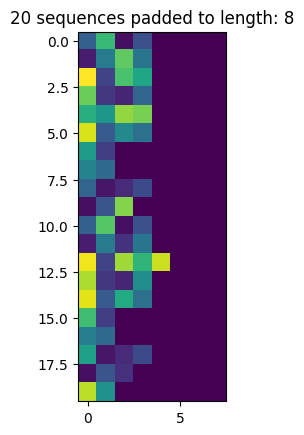

In [6]:
import matplotlib.pyplot as plt
plt.imshow(X)
plt.title(f'{X.shape[0]} sequences padded to length: {X.shape[1]}')
plt.show()

vocabulary size: 50
{'<PAD>': 0, '<UNK>': 1, 'i': 2, 'love': 3, 'this': 4, 'movie': 5, 'what': 6, 'a': 7, 'great': 8, 'day': 9, 'amazing': 10, 'product': 11, 'highly': 12, 'recommend': 13, 'fantastic': 14, 'results': 15, 'very': 16, 'happy': 17, 'pleasant': 18, 'surprise': 19, 'exceeded': 20, 'expectations': 21, 'brilliant': 22, 'idea': 23, 'well': 24, 'executed': 25, 'superb': 26, 'quality': 27, 'wonderful': 28, 'experience': 29, 'with': 30, 'the': 31, 'outcome': 32, 'is': 33, 'excellent': 34, 'hate': 35, 'terrible': 36, 'awful': 37, 'do': 38, 'not': 39, 'buy': 40, 'disappointing': 41, 'unhappy': 42, 'bad': 43, 'poorly': 44, 'horrible': 45, 'worst': 46, 'sad': 47, 'completely': 48, 'unacceptable': 49}


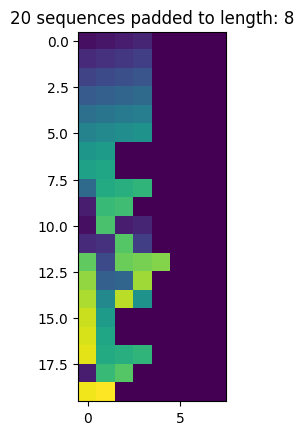

In [7]:
# for PyTorch

import torch

def build_vocab(texts):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for t in texts:
        for w in t.lower().split():
            if w not in vocab:
                vocab[w] = len(vocab)
    return vocab

def encode(text, vocab, max_len=8):
    tokens = [vocab.get(w, 1) for w in text.lower().split()]
    tokens = tokens[:max_len]
    return tokens + [0]*(max_len - len(tokens))

vocab = build_vocab(texts)

print(f"vocabulary size: {len(vocab)}")
print(vocab)

max_len = 8
X = torch.tensor([encode(t, vocab, max_len) for t in texts])

plt.imshow(X.detach().numpy())
plt.title(f'{X.shape[0]} sequences padded to length: {X.shape[1]}')
plt.show()


####  **Embedding and positional encoding**

Each token is represented as embedding vector (of selected length). Vectors are arranged into matrices.

$$
[\texttt{[CLS]},\ t_1, t_2, \ldots, t_n, \texttt{[SEP]}] \xrightarrow{\text{Embedding Layer}}
X = [\mathbf{x}_{\text{CLS}}, \mathbf{x}_1, \ldots, \mathbf{x}_n, \mathbf{x}_{\text{SEP}}]
$$

$$
\xrightarrow{+\ \text{Positional Encoding}}
Z = X + PE
$$

While embeddings store reprezentation of token values, positional encoding gives information on their position within the sentence (document).

$$
\begin{aligned}
PE_{\text{pos},\, 2i} &= \sin\!\left(\frac{\text{pos}}{10000^{\,2i/d_{\text{model}}}}\right) \\
PE_{\text{pos},\, 2i+1} &= \cos\!\left(\frac{\text{pos}}{10000^{\,2i/d_{\text{model}}}}\right)
\end{aligned}
$$

where $d_{\text{model}}$ is the embedding size, pos - a position within the sequence.

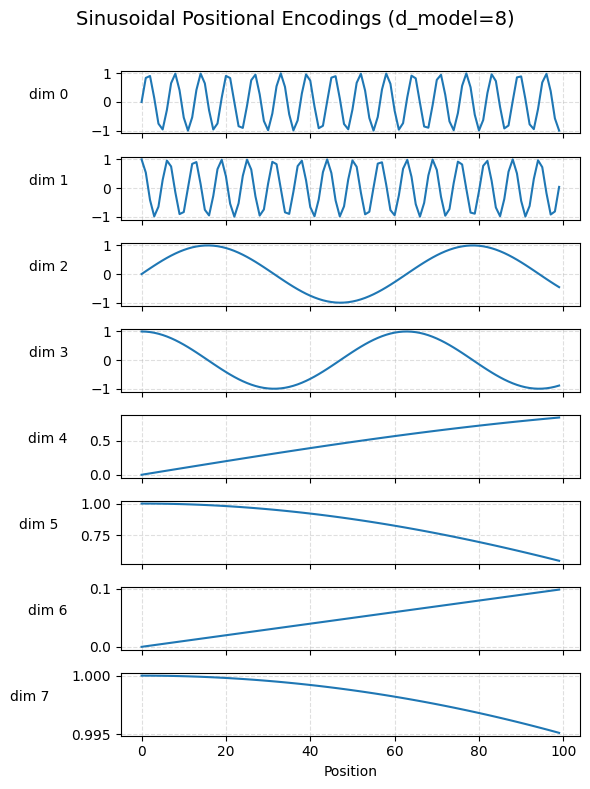

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:, np.newaxis]          # shape (seq_len, 1)
    dimensions = np.arange(d_model)[np.newaxis, :]         # shape (1, d_model)
    angle_rates = 1 / np.power(10000, (2 * (dimensions // 2)) / np.float32(d_model))
    angle_rads = positions * angle_rates

    # Apply sin to even indices, cos to odd indices
    pos_encoding = np.zeros_like(angle_rads)
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return pos_encoding

# Example parameters
seq_len = 100
d_model = 8

pos_encoding = positional_encoding(seq_len, d_model)

# Plot
fig, axes = plt.subplots(d_model, 1, figsize=(6, d_model), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(pos_encoding[:, i])
    ax.set_ylabel(f"dim {i}", rotation=0, labelpad=30, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

axes[-1].set_xlabel("Position")
fig.suptitle(f"Sinusoidal Positional Encodings (d_model={d_model})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Distances between positional encodings of neighboring positions

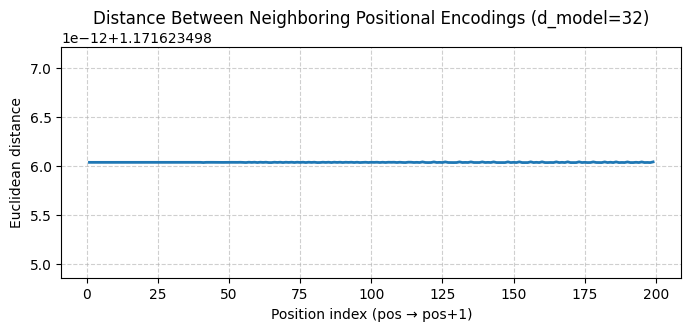

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:, np.newaxis]  # (seq_len, 1)
    i = np.arange(d_model)[np.newaxis, :]          # (1, d_model)
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = positions * angle_rates

    pos_encoding = np.zeros_like(angle_rads)
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return pos_encoding

# Parameters
seq_len = 200
d_model = 32

# Compute positional encodings
pos_encoding = positional_encoding(seq_len, d_model)

# Compute Euclidean distances between neighboring encodings
diffs = np.diff(pos_encoding, axis=0)
distances = np.linalg.norm(diffs, axis=1)

# Plot
plt.figure(figsize=(8, 3))
plt.plot(np.arange(1, seq_len), distances, lw=2)
plt.title(f"Distance Between Neighboring Positional Encodings (d_model={d_model})")
plt.xlabel("Position index (pos → pos+1)")
plt.ylabel("Euclidean distance")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



* Neighboring positions are not identical, but they’re close — roughly 1.1-1.3 units apart in a high-dimensional space.

* This gives the model a smooth positional gradient, while still keeping positions distinct.

#### **Transformer block**
In the next step $Z = X + PE$ (a matrix, which columns are sums of embeddings and positional encoding) is supplied to the transformer block.
$$
Z \xrightarrow{\text{Transformer Encoder Stack (}\times N\text{)}}
$$

$$
\begin{cases}
Q = ZW_Q, \quad K = ZW_K, \quad V = ZW_V \\[6pt]
\text{Attention}(Q,K,V) =
\text{softmax}\!\left(\dfrac{QK^\top}{\sqrt{d_k}}\right)V \\[6pt]
\text{Add & LayerNorm} \\[4pt]
\text{FeedForward: } \text{ReLU}(xW_1 + b_1)W_2 + b_2 \\[4pt]
\text{Add & LayerNorm}
\end{cases}
$$



The most importan element is the *Attention* layer.
For each position in a sequence (e.g., each word in a sentence), a Transformer computes three vectors:
* $Q=ZW_Q$ - query:  *What am I trying to attend to?*
* $K=ZW_K$ - key: *What does this element represent?*
* $V=ZW_V$ - value: *What information do I carry?*

The attention score between two elements is computed as the dot product of the Query and the Key:

$$score(i,j) = Q_i \cdot K_j$$

This score determines how much element $i$ should pay attention to element $j$
After applying softmax, these scores are used to compute a weighted sum of the Values $V$, producing the output of the attention mechanism.

Multi-head attention is an extension of the standard attention mechanism in Transformers. Instead of computing a single attention map, the model uses multiple “heads,” each with its own set of Query, Key, and Value projections. Each head can focus on different aspects of the sequence simultaneously — for example, one head might capture syntactic relationships while another captures semantic dependencies.

#### **Attention map example**

Attention weights shape: torch.Size([1, 1, 4, 4])


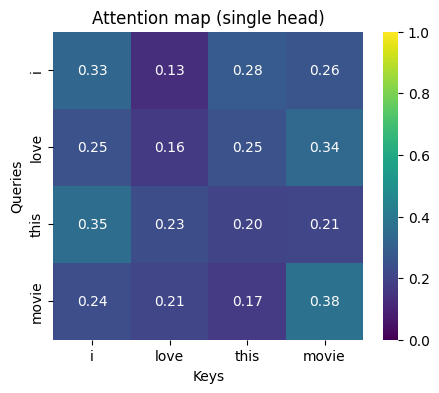

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# === Input data ===
vocab = {"<PAD>":0, "<UNK>":1, "i":2, "love":3, "this":4, "movie":5}
max_len = 4

def encode(text):
    tokens = [vocab.get(w, 1) for w in text.lower().split()]
    tokens = tokens[:max_len]
    return tokens + [0]*(max_len - len(tokens))

sentence = "i love this movie"
words = sentence.split()

x = torch.tensor([encode(sentence)], dtype=torch.long)  # shape: (1, seq_len)

# === Embeddings (random) ===
embed_dim = 8
seq_len = x.shape[1]
vocab_size = 10
embed_dim = 128
num_heads = 1

embedding = nn.Embedding(vocab_size, embed_dim)
x = torch.arange(seq_len) % vocab_size  # [0,1,2,3]
x = embedding(x).unsqueeze(1)  # (seq_len, batch, embed_dim)

# === Multi-head attention ===
multihead_attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=False)

# Self-attention: query, key, value = x
attn_output, attn_weights = multihead_attn(x, x, x, need_weights=True, average_attn_weights=False)

print("Attention weights shape:", attn_weights.shape)
# -> (num_heads, batch, seq_len, seq_len)

# === Visualization of attention map ===
attn_maps = attn_weights.squeeze(1).detach().numpy().reshape(num_heads,4,4)  # (num_heads, seq_len, seq_len)


if num_heads==1:
  fig, ax = plt.subplots(figsize=(5, 4))
  sns.heatmap(attn_maps[0], vmin=0, vmax=1, cmap="viridis",
              xticklabels=words, yticklabels=words,annot=True, fmt=".2f", ax=ax)
  ax.set_title("Attention map (single head)")
  ax.set_xlabel("Keys")
  ax.set_ylabel("Queries")
else:
  fig, axes = plt.subplots(1, num_heads, figsize=(4*num_heads+1, 4))
  for i, ax in enumerate(axes):
      sns.heatmap(attn_maps[i], vmin=0, vmax=1, cmap="viridis",
                  xticklabels=words, yticklabels=words,annot=True, fmt=".2f", ax=ax)
      ax.set_title(f"Head {i+1}")
      ax.set_xlabel("Keys")
      ax.set_ylabel("Queries")

  plt.tight_layout()
plt.show()


#### **Classification**

Transformer block returns a sequence of hidden states:
$$
H_{\text{enc}} = [\mathbf{h}_{\text{CLS}}, \mathbf{h}_1, \ldots, \mathbf{h}_n, \mathbf{h}_{\text{SEP}}]
$$

Depending on the architecture:
* Only the first vector $\mathbf{h}_{\text{CLS}}$ is furher used in classification.
* Or classification is based on all or averaged values of $\mathbf{h}_1, \ldots, \mathbf{h}_n$


**The next steps (classification)**:
$$
\xrightarrow{}
H_{\text{enc}} = [\mathbf{h}_{\text{CLS}}, \mathbf{h}_1, \ldots, \mathbf{h}_n, \mathbf{h}_{\text{SEP}}]
$$

$$
\xrightarrow{\text{Take } \mathbf{h}_{\text{CLS}}}
\mathbf{h}_{\text{out}} = \mathbf{h}_{\text{CLS}} \in \mathbb{R}^{d_{\text{model}}}
$$

$$\text{or}$$

$$
\xrightarrow{\text{Take } \mathbf{h}_1, \ldots, \mathbf{h}_n}
\mathbf{h}_{\text{out}} = \text{Mean}(\mathbf{h}_1, \ldots, \mathbf{h}_n)
$$

$$
\xrightarrow{\text{Classification Head (Dense Layer)}}
\text{logits} = \mathbf{h}_{\text{out}} W_c + b_c
$$

$$
\xrightarrow{\text{Softmax}}
P(y \mid X) = \text{softmax}(\text{logits})
$$

$$
\xrightarrow{\text{Loss (categorical crossentropy)}}
\mathcal{L} = - \sum_{c=1}^{C} \mathbf{1}(y = c) \, \log P(y_c \mid X)
$$



### 3.1.2 Tiny example

#### Tensorflow

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# --- Dane ---
pos_phrases = [
    "i love this movie", "what a great day", "amazing product highly recommend",
    "fantastic results very happy", "pleasant surprise exceeded expectations",
    "brilliant idea well executed", "superb quality", "wonderful experience",
    "happy with the outcome", "this is excellent"
]
neg_phrases = [
    "i hate this movie", "what a terrible day", "awful product do not buy",
    "disappointing results very unhappy", "bad idea poorly executed",
    "horrible quality", "worst experience", "sad with the outcome",
    "this is terrible", "completely unacceptable"
]

texts = pos_phrases + neg_phrases
labels = [1]*len(pos_phrases) + [0]*len(neg_phrases)

# --- Tokenizacja ---
max_len = 8
vectorizer = layers.TextVectorization(max_tokens=1000, output_sequence_length=max_len)
vectorizer.adapt(texts)

vocab_size = len(vectorizer.get_vocabulary())
print("Vocabulary size:", vocab_size)


# --- Funkcja positional encoding ---
def positional_encoding(max_len, d_model):
    positions = np.arange(max_len)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    angle_rads = positions * angle_rates

    pos_encoding = np.zeros_like(angle_rads)
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)


# --- Blok Transformer (1 warstwa) ---
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.norm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.norm2(out1 + ffn_output)


# --- Model ---
embed_dim = 32
num_heads = 2
ff_dim = 64

inputs = keras.Input(shape=(max_len,), dtype=tf.int64)
x = layers.Embedding(vocab_size, embed_dim)(inputs)

# Dodanie positional encoding
pos_encoding = positional_encoding(max_len, embed_dim)
x = x + pos_encoding

# Blok Transformer
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
x = layers.GlobalAveragePooling1D()(x) # no class token
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, x)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# --- Trening ---
X = vectorizer(texts)
y = tf.constant(labels, dtype=tf.float32)

history = model.fit(X, y, epochs=35, batch_size=4, verbose=0)

# --- Test ---
test_phrases = [
    "i really love this product",
    "this is horrible",
    "fantastic quality and great idea",
    "disappointing and bad",
    "wonderful surprise",
    "completely bad experience"
]

test_X = vectorizer(test_phrases)
preds = model.predict(test_X)

for phrase, p in zip(test_phrases, preds):
    print(f"{phrase:45s} → sentiment: {'positive' if p[0]>0.5 else 'negative'} ({p[0]:.2f})")


Vocabulary size: 50

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
i really love this product                    → sentiment: positive (0.73)
this is horrible                              → sentiment: negative (0.50)
fantastic quality and great idea              → sentiment: positive (0.93)
disappointing and bad                         → sentiment: negative (0.11)
wonderful surprise                            → sentiment: positive (0.95)
completely bad experience                     → sentiment: negative (0.09)


#### PyTorch

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F

# --- Dane ---
pos_phrases = [
    "i love this movie", "what a great day", "amazing product highly recommend",
    "fantastic results very happy", "pleasant surprise exceeded expectations",
    "brilliant idea well executed", "superb quality", "wonderful experience",
    "happy with the outcome", "this is excellent"
]
neg_phrases = [
    "i hate this movie", "what a terrible day", "awful product do not buy",
    "disappointing results very unhappy", "bad idea poorly executed",
    "horrible quality", "worst experience", "sad with the outcome",
    "this is terrible", "completely unacceptable"
]

texts = pos_phrases + neg_phrases
labels = torch.tensor([1]*len(pos_phrases) + [0]*len(neg_phrases), dtype=torch.float32)

# --- Prosta tokenizacja ---
from collections import defaultdict

def build_vocab(texts):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for t in texts:
        for w in t.lower().split():
            if w not in vocab:
                vocab[w] = len(vocab)
    return vocab

def encode(text, vocab, max_len=8):
    tokens = [vocab.get(w, 1) for w in text.lower().split()]
    tokens = tokens[:max_len]
    return tokens + [0]*(max_len - len(tokens))

vocab = build_vocab(texts)
max_len = 8
X = torch.tensor([encode(t, vocab, max_len) for t in texts])

vocab_size = len(vocab)
embed_dim = 32
num_heads = 2
ff_dim = 64

# --- Positional Encoding ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# --- Transformer model ---
class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim, max_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc1 = nn.Linear(embed_dim, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoding(x)
        x = self.transformer(x)
        x = x.mean(dim=1)  # Global average pooling (no class token)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze(-1)

# --- Trening ---
model = MiniTransformer(vocab_size, embed_dim, num_heads, ff_dim, max_len)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

for epoch in range(50):
    optimizer.zero_grad()
    preds = model(X)
    loss = criterion(preds, labels)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        acc = ((preds > 0.5).float() == labels).float().mean()
        print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.4f} | Acc: {acc.item():.2f}")

# --- Test ---
test_phrases = [
    "i really love this product",
    "this is horrible",
    "fantastic quality and great idea",
    "disappointing and bad"
]

X_test = torch.tensor([encode(t, vocab, max_len) for t in test_phrases])
preds = model(X_test).detach()

for t, p in zip(test_phrases, preds):
    print(f"{t:45s} → sentiment: {'positive' if p>0.5 else 'negative'} ({p.item():.2f})")


Epoch 10 | Loss: 0.6729 | Acc: 0.80
Epoch 20 | Loss: 0.6361 | Acc: 0.90
Epoch 30 | Loss: 0.4981 | Acc: 1.00
Epoch 40 | Loss: 0.2505 | Acc: 1.00
Epoch 50 | Loss: 0.0882 | Acc: 1.00
i really love this product                    → sentiment: positive (0.91)
this is horrible                              → sentiment: negative (0.09)
fantastic quality and great idea              → sentiment: positive (0.92)
disappointing and bad                         → sentiment: positive (0.76)


### 3.1.3 IMDB Reviews

In [14]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Load dataset ---
max_words = 10000  # vocabulary size
max_len = 200      # max review length

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_words)
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (25000, 200), Test shape: (25000, 200)


In [16]:
import tensorflow_datasets as tfds
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Load raw IMDB text dataset ---
ds_train = tfds.load('imdb_reviews', split='train', as_supervised=True)
ds_test = tfds.load('imdb_reviews', split='test', as_supervised=True)

# Convert to Python lists
train_texts, train_labels = [], []
for text, label in tfds.as_numpy(ds_train):
    train_texts.append(text.decode("utf-8"))
    train_labels.append(label)

test_texts, test_labels = [], []
for text, label in tfds.as_numpy(ds_test):
    test_texts.append(text.decode("utf-8"))
    test_labels.append(label)

print(f"Loaded {len(train_texts)} training and {len(test_texts)} test samples.")


Loaded 25000 training and 25000 test samples.


In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

max_words = 10000   # keep top 10k words
max_len = 200       # truncate/pad reviews to 200 tokens

# --- Fit tokenizer on training texts ---
tokenizer = Tokenizer(num_words=max_words, oov_token="<UNK>")
tokenizer.fit_on_texts(train_texts)

# --- Convert to sequences ---
X_train = tokenizer.texts_to_sequences(train_texts)
X_test = tokenizer.texts_to_sequences(test_texts)

# --- Pad sequences ---
X_train = pad_sequences(X_train, maxlen=max_len, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=max_len, padding='post', truncating='post')

y_train = np.array(train_labels)
y_test = np.array(test_labels)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (25000, 200), Test shape: (25000, 200)


### TF model

In [18]:
from tensorflow.keras import layers, models

embed_dim = 12
num_heads = 1
ff_dim = 64 # feed forward dimension

inputs = layers.Input(shape=(max_len,))
x = layers.Embedding(max_words, embed_dim)(inputs)

# Add a simple Transformer encoder block
x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(ff_dim, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_tf = models.Model(inputs, outputs)
model_tf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_tf.summary()
hist = model_tf.fit(X_train, y_train, epochs=10, batch_size=512, validation_split=0.2)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 12)   │    120,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 12)   │        624 │ embedding_1[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 12)        │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │        832 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 121,521 (474.69 KB)

 Trainable params: 121,521 (474.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5262 - loss: 0.6921 - val_accuracy: 0.6356 - val_loss: 0.6869
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6767 - loss: 0.6559 - val_accuracy: 0.7510 - val_loss: 0.5903
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7997 - loss: 0.4843 - val_accuracy: 0.8296 - val_loss: 0.4071
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8558 - loss: 0.3515 - val_accuracy: 0.8564 - val_loss: 0.3482
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8776 - loss: 0.3009 - val_accuracy: 0.8672 - val_loss: 0.3278
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8977 - loss: 0.2636 - val_accuracy: 0.8638 - val_loss: 0.3318
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9070 - loss: 0.2410 - val_accuracy: 0.8596 - val_loss: 0.3441
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9180 - loss: 0.2201 - val_accuracy: 0.8632 - v

Text(0, 0.5, 'Accuracy')

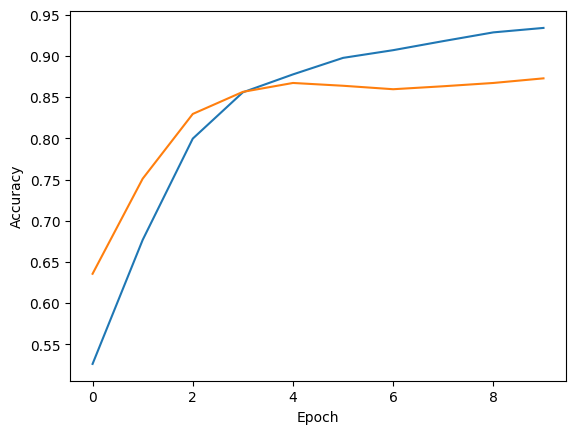

In [19]:
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy'], label='accuracy')
plt.plot(hist.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

📈 Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86     12500
    Positive       0.86      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



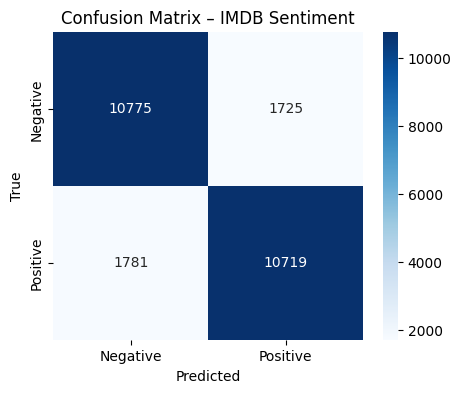

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Evaluate model on test data ---
y_pred_probs = model_tf.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

# --- Classification report ---
print("\n📈 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
labels = ["Negative", "Positive"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – IMDB Sentiment")
plt.show()


### Pytorch

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
device = "cuda" if torch.cuda.is_available() else "cpu"
X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)

# import torch
# import torch.nn as nn
# import torch.nn.functional as F

class SentimentTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, ff_dim=256, num_layers=1, max_len=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoding = self._build_positional_encoding(max_len, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads,
                                                   dim_feedforward=ff_dim, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, 1)

    def _build_positional_encoding(self, max_len, d_model):
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe.unsqueeze(0)  # shape (1, max_len, d_model)

    def forward(self, x):
        seq_len = x.size(1)
        x = self.embedding(x) + self.pos_encoding[:, :seq_len, :].to(x.device)
        x = self.transformer(x)
        x = x.mean(dim=1)  # Global average pooling
        x = torch.sigmoid(self.fc(x))
        return x.squeeze(-1)

model_torch = SentimentTransformer(max_words).to(device)
optimizer = optim.Adam(model_torch.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# --- Training loop ---
for epoch in range(10):
    model_torch.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model_torch(xb).squeeze()
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}")


Epoch 1: loss=0.6673
Epoch 2: loss=0.5328
Epoch 3: loss=0.4175
Epoch 4: loss=0.3397
Epoch 5: loss=0.2957
Epoch 6: loss=0.2713
Epoch 7: loss=0.2347
Epoch 8: loss=0.2095
Epoch 9: loss=0.1921
Epoch 10: loss=0.1729


In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- Evaluate on the test set ---
model_torch.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for i in range(0, len(X_test_t), 512):
        xb = X_test_t[i:i+512].to(device)
        preds = model_torch(xb).squeeze().cpu()
        y_pred.extend((preds > 0.5).int().numpy())
        y_true.extend(y_test_t[i:i+512].numpy())

# # --- Classification report ---
# print("\n📈 Classification Report:")
# print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

# # --- Confusion matrix ---
# cm = confusion_matrix(y_true, y_pred)
# labels = ["Negative", "Positive"]

# plt.figure(figsize=(5, 4))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#             xticklabels=labels, yticklabels=labels)
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix – PyTorch IMDB Sentiment")
plt.show()


              precision    recall  f1-score   support

    negative       0.80      0.88      0.84     12500
    positive       0.87      0.78      0.82     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



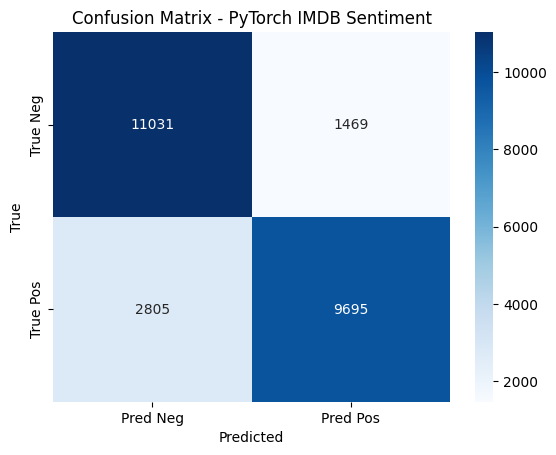

In [24]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_torch.eval()

# --- Create dataset & dataloader ---
test_ds = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

# --- Evaluation ---
y_true, y_pred = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model_torch(xb).squeeze()
        y_true.extend(yb.cpu().numpy())
        y_pred.extend((preds > 0.5).int().cpu().numpy())

# --- Metrics ---
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred Neg", "Pred Pos"],
            yticklabels=["True Neg", "True Pos"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - PyTorch IMDB Sentiment")
plt.show()


### TODO

Efficiency of determined classifier depend on several parameters, related to:
* Preprocessing: sequence length and vocabulary size
* Architecture: embedding dimension, number of heads, size of the hidden layer (feed forward dimensionon)
* Training process: number of epochs and learning rate

Prepare 8 configurations (including various preprocessing parameters). Report results in the table summarizing parameter values and classification results (report accuracy, precision, recall, F1).

Display a few reviews from the dataset and print classification result


In [27]:
# Efficiency of determined classifier depend on several parameters, related to:

# Preprocessing: sequence length and vocabulary size
# Architecture: embedding dimension, number of heads, size of the hidden layer (feed forward dimensionon)
# Training process: number of epochs and learning rate
# Prepare 8 configurations (including various preprocessing parameters). Report results in the table summarizing parameter values and classification results (report accuracy, precision, recall, F1).

# Display a few reviews from the dataset and print classification result

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA dostępne:", torch.cuda.is_available())

def run_model(seq_len, vocab_size, embed_dim, heads, ff_dim, epochs, lr):

  test_ds = TensorDataset(X_test_t, y_test_t)
  test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

  model = SentimentTransformer(
      vocab_size=vocab_size,
      embed_dim=embed_dim,
      num_heads=heads,
      ff_dim=ff_dim,
      num_layers=1,
      max_len=X_train.shape[1]
  ).to(device)

  optimizer = optim.Adam(model.parameters(), lr=lr)
  criterion = nn.BCELoss()

  for epoch in range(epochs):
      model.train()
      for xb, yb in train_loader:
          xb, yb = xb.to(device), yb.to(device)
          xb = torch.clamp(xb, max=vocab_size-1)
          pred = model(xb).squeeze()
          loss = criterion(pred, yb)
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

  model.eval()
  y_true, y_pred = [], []
  with torch.no_grad():
      for xb, yb in test_loader:
          xb, yb = xb.to(device), yb.to(device)
          xb = torch.clamp(xb, max=vocab_size-1)
          preds = model(xb).squeeze()
          y_true.extend(yb.cpu().numpy())
          y_pred.extend((preds > 0.5).int().cpu().numpy())

  random_idx = np.random.randint(0, len(X_test))
  review_tokens = X_test_t[random_idx].unsqueeze(0).to(device)
  true_val = y_test_t[random_idx].item()
  pred = model(review_tokens).item()
  print(f"Test text: {test_texts[random_idx]}")
  print("Prediction:", "Positive" if pred > 0.5 else "Negative ", f"True value: ", "Positive" if true_val == 1.0 else "Negative")
  print("Score:", round(pred, 4), "\n")

  return {
      "accuracy" : accuracy_score(y_true, y_pred),
      "precision" : precision_score(y_true, y_pred),
      "recall" : recall_score(y_true, y_pred),
      "f1" : f1_score(y_true, y_pred)
  }

PyTorch version: 2.9.1+cu130
CUDA dostępne: True


In [28]:

%env CUDA_LAUNCH_BLOCKING=1

# I didn't change the sequence length, because I've got some Cuda erros, that I couldn't fix ...


configs = [
    # Conf_name, seq_len, vocab_size, embed_dim, heads, ff_dim, epochs, lr
    ("C1", 128, 10000, 64, 2, 128, 5, 1e-3),
    ("C2", 128, 10000, 128, 4, 256, 5, 1e-3),
    ("C3", 256, 10000, 64, 4, 256, 10, 1e-3),
    ("C4", 256, 10000, 128, 4, 256, 5, 5e-4),
    ("C5", 128, 10000, 128, 2, 128, 10, 1e-3),
    ("C6", 256, 10000, 64, 4, 128, 10, 5e-4),
    ("C7", 256, 10000, 128, 4, 256, 10, 5e-4),
    ("C8", 128, 10000, 64, 2, 128, 5, 5e-4)
]

# For readability purposes I rewrite this configs, but I wont run this code once again, it will take too long...

# configs_dict = [
#     {"Conf_name": "C1", "seq_len": 128, "vocab_size": 10000, "embed_dim": 64, "heads": 2, "ff_dim":128, "epochs": 5, "lr":1e-3},
#     {"Conf_name": "C2", "seq_len": 128, "vocab_size": 10000, "embed_dim": 128, "heads": 4, "ff_dim":256, "epochs": 5, "lr":1e-3},
#     {"Conf_name": "C3", "seq_len": 256, "vocab_size": 10000, "embed_dim": 64, "heads": 4, "ff_dim":256, "epochs": 10, "lr":1e-3},
#     {"Conf_name": "C4", "seq_len": 256, "vocab_size": 10000, "embed_dim": 128, "heads": 4, "ff_dim":256, "epochs": 5, "lr":5e-4},
#     {"Conf_name": "C5", "seq_len": 128, "vocab_size": 10000, "embed_dim": 128, "heads": 2, "ff_dim":128, "epochs": 10, "lr":1e-3},
#     {"Conf_name": "C6", "seq_len": 256, "vocab_size": 10000, "embed_dim": 64, "heads": 4, "ff_dim":128, "epochs": 10, "lr":5e-4},
#     {"Conf_name": "C7", "seq_len": 256, "vocab_size": 10000, "embed_dim": 128, "heads": 4, "ff_dim":256, "epochs": 10, "lr":5e-4},
#     {"Conf_name": "C8", "seq_len": 128, "vocab_size": 10000, "embed_dim": 64, "heads": 2, "ff_dim":128, "epochs": 5, "lr":5e-4}
# ]

results = {}
for name, seq_len, vocab, emb, heads, ff, epochs, lr in configs:
    print(f"\nRunning {name}...")
    results[name] = run_model(seq_len, vocab, emb, heads, ff, epochs, lr)


env: CUDA_LAUNCH_BLOCKING=1

Running C1...
Test text: Sometimes, but very rarely, a movie tells a story so well that it almost becomes difficult. This movie tells several stories so well simultaneously that it was the first few times a movie I could not watch to completion. It was too real....and the characters SO STRONG that watching it became a personal struggle. Seeing these three men and their families deal with their hardships, one in particular, often hit me too hard. Now, I have watched in its entirety without interruption several times, and I realize what I always suspected. This movie is a masterpiece. The writing, the acting, the blending of several stories without being even the least bit choppy, everything about this movie is exceptional. Seven Academy Awards? No wonder, it certainly must have deserved them.
Prediction: Positive True value:  Positive
Score: 0.8714 


Running C2...
Test text: i went to see this because i have some friends in the ukraine. but the film moved m

In [29]:
import pandas as pd
df_results = pd.DataFrame(results).T
df_results

,accuracy,precision,recall,f1
C1,0.80368,0.857641,0.72824,0.787661
C2,0.83648,0.825340,0.85360,0.839232
C3,0.83892,0.814911,0.87704,0.844835
C4,0.80540,0.847773,0.74448,0.792776
C5,0.83340,0.831464,0.83632,0.833885
C6,0.81832,0.845100,0.77952,0.810986
C7,0.82204,0.863279,0.76528,0.811331
C8,0.77228,0.800106,0.72592,0.761210


In [30]:
sample_ids = [11, 123, 204, 321, 5]

for i in sample_ids:
    review_tokens = X_test_t[i].unsqueeze(0).to(device)
    true_val = y_test_t[i].item()
    pred = model_torch(review_tokens).item()

    print(f"Test text: {test_texts[i]}")
    print("Prediction:", "Positive" if pred > 0.5 else "Negative ", f"True value: {true_val}")
    print("Score:", round(pred, 4), "\n")

Test text: I kind of like Bam Margera, so I was curious. <br /><br />But watching a home production with somebody elses friends and family, with a decent camera and a sound guy, just isn't good film-making. <br /><br />Writing, direction, acting and editing is abysmal at best. But I sat through half of it. And why?<br /><br />This film gives perfect examples of what not to do, it is a film student's dream of what to avoid at every stage of the process. Cram it into film school curiculums all over the joint!<br /><br />So thanx Bam! Now I know Jackass is for real - cause you ain't looking to win an Oscar, dude:)
Prediction: Negative  True value: 0.0
Score: 0.0405 

Test text: This two disc set is incredible! If you're like me and never had the opportunity to actually see the band live, then this is the next best thing. Jimmy Page, who in my opinion is the second best guitarist ever to walk the face of the earth (second only to Slowfingers himself), He puts on an amazing show in every pi

# 3.2 Visual transformer (ViT)

Vision Transformers (ViTs) are models that apply the Transformer architecture directly to images by representing them as sequences of patch embeddings, allowing self-attention to capture relationships across the entire image without relying on convolutional operations.

**Patches**

Instead of tokens from text, ViT creates “visual tokens.”
An input image of shape $H\times W \times C$ is split into fixed size non-overlapping patches of size $P \times P \times C$. Hence, an image is represented by a sequence of visual tokens of length $N$, where $N = \frac{H \times W}{P^2}$.

Next, each patch $\mathbf{x}_i \in \mathbb{R}^{P \times P \times C}$  is flattened into a vector:

$$
\mathbf{x}_i \rightarrow \mathrm{vec}(\mathbf{x}_i) \in \mathbb{R}^{P^2 C}
$$

---
**Linear patch embedding**

Each flattened patch is linearly projected to a fixed-dimensional embedding space of dimension $D$:

$$
\mathbf{z}_i = \mathbf{W}_E \, \mathbf{x}_i + \mathbf{b}_E,
\quad \mathbf{W}_E \in \mathbb{R}^{D \times (P^2 C)}
$$

This produces a sequence of embedded tokens:

$$
\mathbf{Z} = [\mathbf{z}_1, \mathbf{z}_2, \ldots, \mathbf{z}_N]
$$

The matrix $\mathbf{W}_E$ is learnable.

---
**Class Token**

A learnable *classification token* $\mathbf{z}_\text{CLS} \in \mathbb{R}^{D} $ **can be** inserted at the beginning of the sequence:

$$
\mathbf{Z}' = [\mathbf{z}_\text{CLS}, \mathbf{z}_1, \ldots, \mathbf{z}_N]
$$

---
**Positional Embedding**

Transformer has no inherent notion of spatial order. Information on positions of patches in the image is encoded as embedding vectors.

Patch positions are indexed in images along rows or columns, and form a sequences of size $N$, e.g:

(0,0), (0,1), (0,2), ..., (1,0), (1,1), ...

Typically, learnable embeddings $ \mathbf{PE} \in \mathbb{R}^{(N+1) \times D} $ are used.


$$
\mathbf{Z}'' = \mathbf{Z}' + \mathbf{PE}
$$

---
**Transformer Encoder Block**

* Transformer Encoder Block
  * Self-Attention Block
  * MLP (Multilayer Perceptron

Transformerr Encoder Blocks can be repeated several times. It is believed that subsequent blocks catch higher level features.

The output is a sequence of hidden states $H_{\text{enc}} = [\mathbf{h}_{\text{CLS}}, \mathbf{h}_1, \ldots, \mathbf{h}_n, \mathbf{h}_{\text{SEP}}]$

---
**Dense and output layers**

If class token is used, its value $\mathbf{h}_{\text{CLS}}$ is extracted. In the opposite case mean value (sometimes all values) of $\mathbf{h}_1, \ldots, \mathbf{h}_n$ is used in the final block making classification.

## 3.2.1 Example of patches (CIFAR 10)

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
# (50000, 32, 32, 3) and (10000, 32, 32, 3)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 36s 0us/step
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


In [32]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


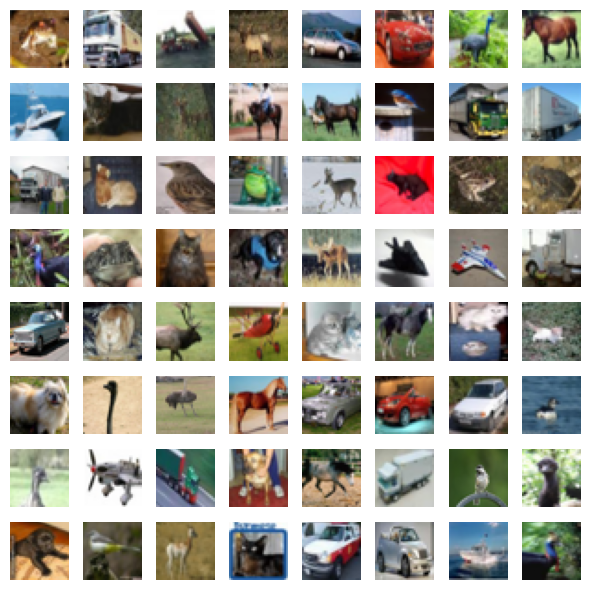

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(8, 8, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    patch = x_train[i]
    ax.imshow(patch)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [39]:

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )
        patch_dims = tf.shape(patches)[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

xp = Patches(patch_size=patch_size)(x_train[19].reshape(1, 32, 32, 3))

NameError: name 'patch_size' is not defined

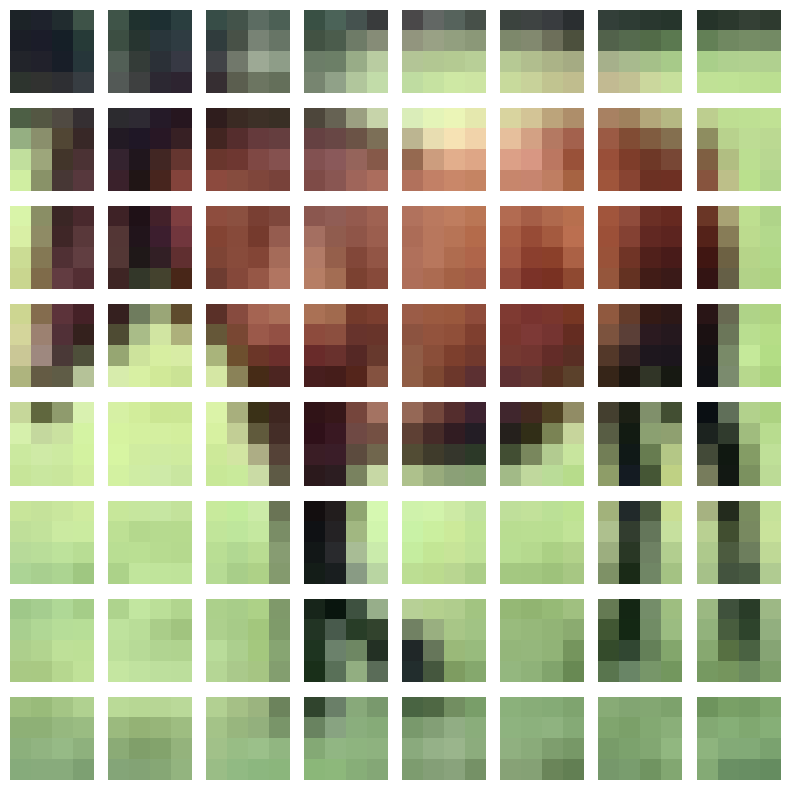

In [40]:
import matplotlib.pyplot as plt
import tensorflow as tf

patch_size = 4

xp = Patches(patch_size=patch_size)(x_train[7].reshape(1, 32, 32, 3))

patches = xp[0].numpy().reshape(-1, patch_size, patch_size, 3)

fig, axes = plt.subplots(x_train.shape[1]//patch_size, x_train.shape[1]//patch_size, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    patch = patches[i]
    ax.imshow(patch)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 3.2.1 Fashion MNIST example (Tensorflow)

In this example class token is not used. Instead, all values of hidden states are used for final classification.

In [41]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- 1. Load Fashion-MNIST ---
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train[..., None] / 255.0
x_test = x_test[..., None] / 255.0

# --- 2. Define patch extraction and encoder layers ---
patch_size = 4
num_patches = (x_train.shape[1] // patch_size) ** 2
projection_dim = 64

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )
        patch_dims = tf.shape(patches)[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        x = self.projection(patches)
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        pos_emb = self.position_embedding(positions)
        pos_emb = tf.expand_dims(pos_emb, axis=0)
        return x + pos_emb

# --- 3. Build ViT model ---
def create_vit_classifier():
    inputs = layers.Input(shape=(28,28,1))
    patches = Patches(patch_size)(inputs)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Transformer blocks
    for _ in range(4):
        # LayerNorm + Multi-Head Self Attention
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=4, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])

        # MLP block
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = layers.Dense(projection_dim * 2, activation=tf.nn.gelu)(x3)
        x3 = layers.Dense(projection_dim)(x3)
        encoded_patches = layers.Add()([x3, x2])

    # Classification head
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    logits = layers.Dense(10)(representation)

    return keras.Model(inputs=inputs, outputs=logits)

model = create_vit_classifier()
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

# --- 4. Train ---
model.fit(x_train, y_train, batch_size=128, epochs=20, validation_split=0.1)

# --- 5. Evaluate ---
model.evaluate(x_test, y_test)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
172/422 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.5687 - loss: 1.4465

KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Class names for Fashion-MNIST ---
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


# --- 2. Predict on test set ---
y_pred_logits = model.predict(x_test)
y_pred = np.argmax(y_pred_logits, axis=1)

# --- 3. Classification report ---
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# --- 4. Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Fashion-MNIST Confusion Matrix")
plt.show()


**GELU** is a smooth function similart to ReLU commonly used in Transformer models

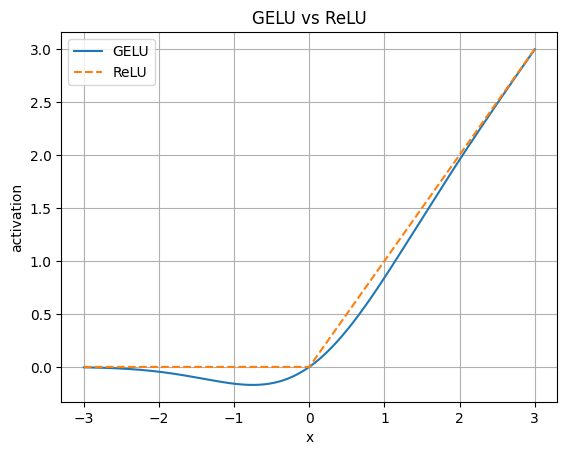

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# Exact GELU
def gelu(x):
    return 0.5 * x * (1 + erf(x / np.sqrt(2)))

x = np.linspace(-3, 3, 500)
y = gelu(x)

plt.plot(x, y, label="GELU")
plt.plot(x, np.maximum(0, x), '--', label="ReLU")
plt.title("GELU vs ReLU")
plt.xlabel("x")
plt.ylabel("activation")
plt.grid(True)
plt.legend()
plt.show()


## 3.2.2 Fashion MNIST with class token (TF)

In [43]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- 1. Load Fashion-MNIST ---
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train[..., None] / 255.0
x_test = x_test[..., None] / 255.0


# --- 2. Define patch extraction and encoder layers ---
patch_size = 4
num_patches = (x_train.shape[1] // patch_size) ** 2
projection_dim = 64

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )
        patch_dims = tf.shape(patches)[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches + 1,  # +1 na class token
            output_dim=projection_dim
        )
        # Inicjalizujemy class token jako trenowalny wektor
        self.class_token = self.add_weight(
            name="class_token",
            shape=(1, 1, projection_dim),
            initializer="random_normal",
            trainable=True,
        )

    def call(self, patches):
        batch_size = tf.shape(patches)[0]
        x = self.projection(patches)

        # Broadcast class token for each batch element
        class_token = tf.broadcast_to(self.class_token, [batch_size, 1, projection_dim])

        # Class token is inserted at the beginning
        x = tf.concat([class_token, x], axis=1)

        # Token positions (add 1 because of the class token )
        positions = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        pos_emb = self.position_embedding(positions)
        pos_emb = tf.expand_dims(pos_emb, axis=0)
        return x + pos_emb


# --- 3. Build ViT model ---
def create_vit_classifier():
    inputs = layers.Input(shape=(28, 28, 1))
    patches = Patches(patch_size)(inputs)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Transformer blocks
    for _ in range(4):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=4, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = layers.Dense(projection_dim * 2, activation=tf.nn.gelu)(x3)
        x3 = layers.Dense(projection_dim)(x3)
        encoded_patches = layers.Add()([x3, x2])

    # Classification head (tylko class token)
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    # extract the first token = class token
    class_token_output = representation[:, 0, :]
    representation = layers.Dropout(0.5)(class_token_output)
    logits = layers.Dense(10)(representation)

    return keras.Model(inputs=inputs, outputs=logits)


# --- 4. Compile & train ---
model = create_vit_classifier()
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

model.summary()

# --- 5. Train ---
model.fit(x_train, y_train, batch_size=128, epochs=20, validation_split=0.1)

# --- 6. Evaluate ---
model.evaluate(x_test, y_test)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_2 (Patches) │ (None, None, 16)  │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_1     │ (None, 50, 64)    │      4,352 │ patches_2[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ patch_encoder_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 50, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 50, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 50, 64)    │      8,256 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 50, 64)    │          0 │ dense_18[0][0],   │
│                     │                   │            │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 50, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 50, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 50, 64)    │      8,256 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 50, 64)    │          0 │ dense_20[0][0],   │
│                     │                   │            │ add_11[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 337,930 (1.29 MB)

 Trainable params: 337,930 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
 91/422 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.2552 - loss: 2.4056

KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Class names for Fashion-MNIST ---
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


# --- 2. Predict on test set ---
y_pred_logits = model.predict(x_test)
y_pred = np.argmax(y_pred_logits, axis=1)

# --- 3. Classification report ---
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# --- 4. Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Fashion-MNIST Confusion Matrix")
plt.show()


## 3.2.3 Fashion MNIST Pytorch (with class token)

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# --- Data ---
transform = transforms.Compose([
    # transforms.Resize(32),
    transforms.ToTensor()
])
train_data = datasets.FashionMNIST(root='.', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='.', train=False, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)

# --- Model ---
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=1, patch_size=4, emb_size=128, img_size=28, use_cls_token=True):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, emb_size, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size) ** 2
        if use_cls_token:
          self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
          self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, emb_size))
        else:
          self.pos_embed = nn.Parameter(torch.randn(1, num_patches, emb_size))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)  # (B, num_patches, emb_size)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        return x

class ViT(nn.Module):
    def __init__(self, num_classes=10, emb_size=128, depth=4, n_heads=8, patch_size=4, img_size=28, use_cls_token=True):
        super().__init__()
        self.patch_embed = PatchEmbedding(1, patch_size, emb_size, img_size, use_cls_token)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_size, nhead=n_heads, dim_feedforward=emb_size*2, dropout=0.1, activation='gelu', batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.head = nn.Linear(emb_size, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.encoder(x)
        cls_output = x[:, 0]
        return self.head(cls_output)

# --- Training ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ViT().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# --- Evaluation ---
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
print(f"Test Accuracy: {correct/total:.4f}")


100.0%
100.0%
100.0%
100.0%


Epoch 1, Loss: 0.8119
Epoch 2, Loss: 0.4698
Epoch 3, Loss: 0.4125
Epoch 4, Loss: 0.3785
Epoch 5, Loss: 0.3584
Epoch 6, Loss: 0.3384
Epoch 7, Loss: 0.3220
Epoch 8, Loss: 0.3107
Epoch 9, Loss: 0.2995
Epoch 10, Loss: 0.2907
Epoch 11, Loss: 0.2818
Epoch 12, Loss: 0.2752
Epoch 13, Loss: 0.2670
Epoch 14, Loss: 0.2608
Epoch 15, Loss: 0.2530
Epoch 16, Loss: 0.2481
Epoch 17, Loss: 0.2412
Epoch 18, Loss: 0.2360
Epoch 19, Loss: 0.2273
Epoch 20, Loss: 0.2221
Test Accuracy: 0.8919


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.86      0.85      1000
     Trouser       0.97      0.99      0.98      1000
    Pullover       0.81      0.81      0.81      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.83      0.81      0.82      1000
      Sandal       0.94      0.98      0.96      1000
       Shirt       0.72      0.73      0.72      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.93      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



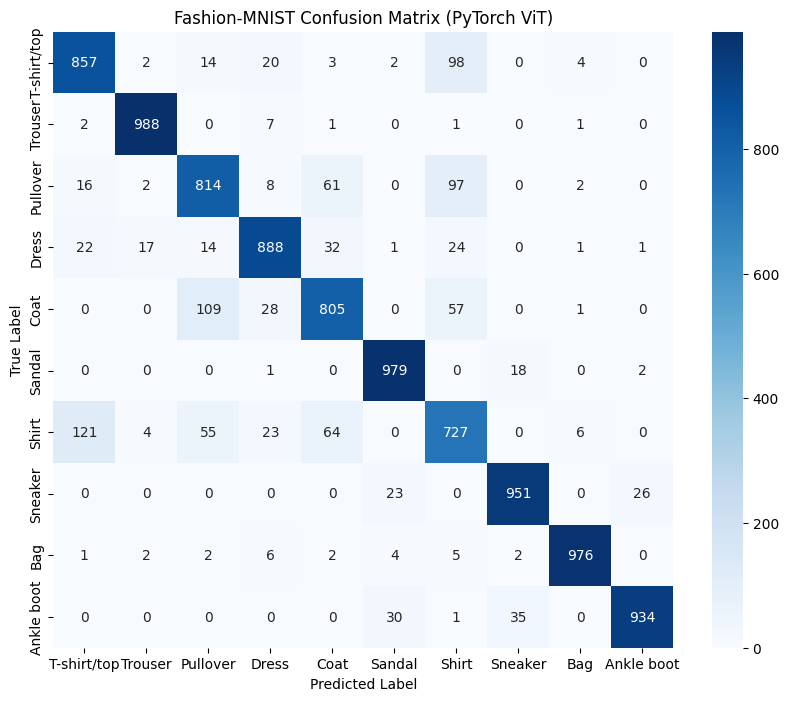

In [45]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# --- 1. Define class names ---
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# --- 2. Get predictions on test set ---
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_labels).numpy()

# --- 3. Classification report ---
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# --- 4. Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Fashion-MNIST Confusion Matrix (PyTorch ViT)")
plt.show()


## 3.2.4 TODO

* Perform experiments on CIFAR-10 dataset. Observe, that image shapes are (32,32,3)
* Test at least 4 configurations using TF or Pytorch. What can be changed:
  * numbers of transformers blocks
  * embedding dimensions
  * using class tokens (or not)
  * patch size (2,4,8)
* Summarize results in a table.
* Include confusion matrix (use correct labels) and discuss which images were misclassified (e.g. aircrafts taken as frogs?)


In [46]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=1, patch_size=4, emb_size=128, img_size=28, use_cls_token=True):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, emb_size, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size) ** 2
        self.use_cls_token = use_cls_token
        if use_cls_token:
          self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
          self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, emb_size))
        else:
          self.pos_embed = nn.Parameter(torch.randn(1, num_patches, emb_size))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)  # (B, num_patches, emb_size)
        if self.use_cls_token:
          cls_tokens = self.cls_token.expand(B, -1, -1)
          x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        return x

class ViT(nn.Module):
  def __init__(self, num_classes=10, emb_size=128, depth=4, n_heads=8, patch_size=4, img_size=28, use_cls_token=True):
      super().__init__()
      self.patch_embed = PatchEmbedding(1, patch_size, emb_size, img_size, use_cls_token)
      encoder_layer = nn.TransformerEncoderLayer(
          d_model=emb_size, nhead=n_heads, dim_feedforward=emb_size*2, dropout=0.1, activation='gelu', batch_first=True
      )
      self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
      self.head = nn.Linear(emb_size, num_classes)

  def forward(self, x):
      x = self.patch_embed(x)
      x = self.encoder(x)
      if self.patch_embed.use_cls_token:
        cls_output = x[:, 0]
      else:
        cls_output = x.mean(dim=1)
      return self.head(cls_output)


Training config C1...
Epoch 1, Loss: 1.1261
Epoch 2, Loss: 0.6232
Epoch 3, Loss: 0.5443
Epoch 4, Loss: 0.5019
Epoch 5, Loss: 0.4693
Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.79      0.80      1000
     Trouser       0.99      0.94      0.97      1000
    Pullover       0.72      0.70      0.71      1000
       Dress       0.74      0.91      0.82      1000
        Coat       0.71      0.73      0.72      1000
      Sandal       0.93      0.92      0.93      1000
       Shirt       0.64      0.53      0.58      1000
     Sneaker       0.90      0.89      0.89      1000
         Bag       0.96      0.95      0.95      1000
  Ankle boot       0.90      0.94      0.92      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



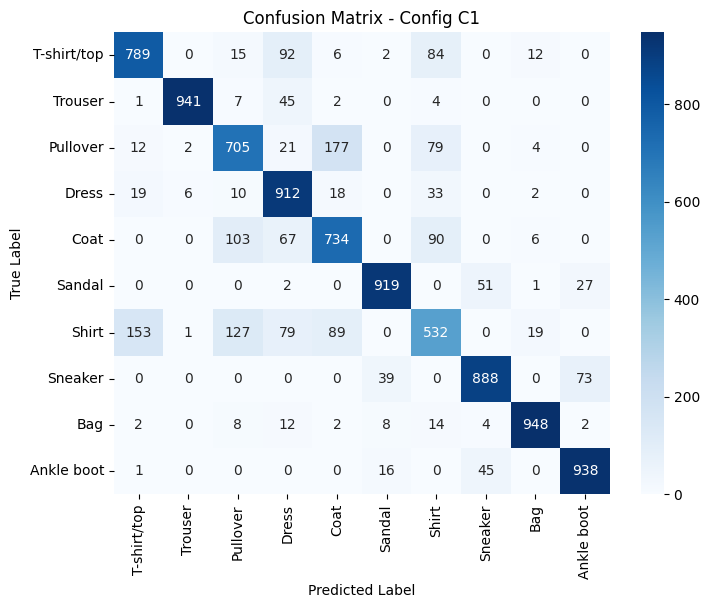

Training config C2...
Epoch 1, Loss: 0.8089
Epoch 2, Loss: 0.4715
Epoch 3, Loss: 0.4135
Epoch 4, Loss: 0.3842
Epoch 5, Loss: 0.3583
Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.76      0.80      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.81      0.72      0.77      1000
       Dress       0.87      0.89      0.88      1000
        Coat       0.73      0.84      0.78      1000
      Sandal       0.96      0.94      0.95      1000
       Shirt       0.65      0.68      0.66      1000
     Sneaker       0.93      0.94      0.93      1000
         Bag       0.94      0.97      0.96      1000
  Ankle boot       0.94      0.95      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



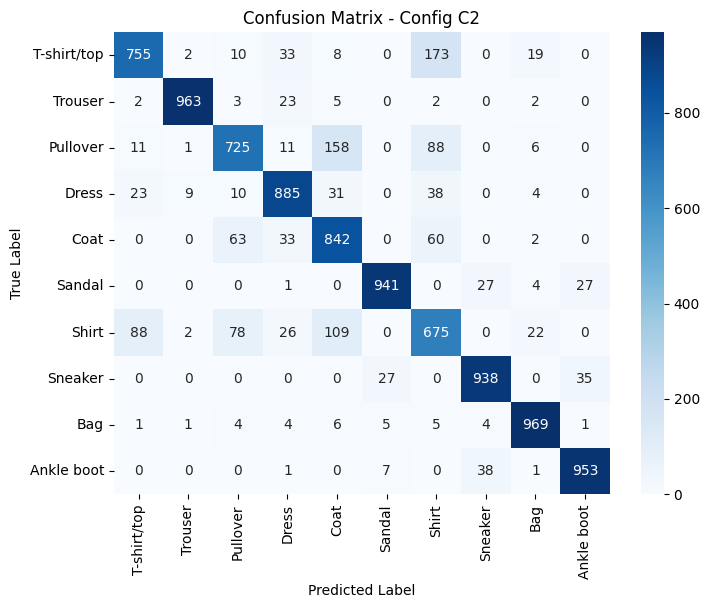

Training config C3...
Epoch 1, Loss: 0.9761
Epoch 2, Loss: 0.5064
Epoch 3, Loss: 0.4436
Epoch 4, Loss: 0.4036
Epoch 5, Loss: 0.3784
Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.78      0.80      1000
     Trouser       0.96      0.97      0.96      1000
    Pullover       0.72      0.81      0.76      1000
       Dress       0.80      0.91      0.85      1000
        Coat       0.79      0.70      0.75      1000
      Sandal       0.96      0.93      0.95      1000
       Shirt       0.68      0.61      0.64      1000
     Sneaker       0.90      0.95      0.93      1000
         Bag       0.96      0.96      0.96      1000
  Ankle boot       0.95      0.94      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.85     10000
weighted avg       0.86      0.86      0.85     10000



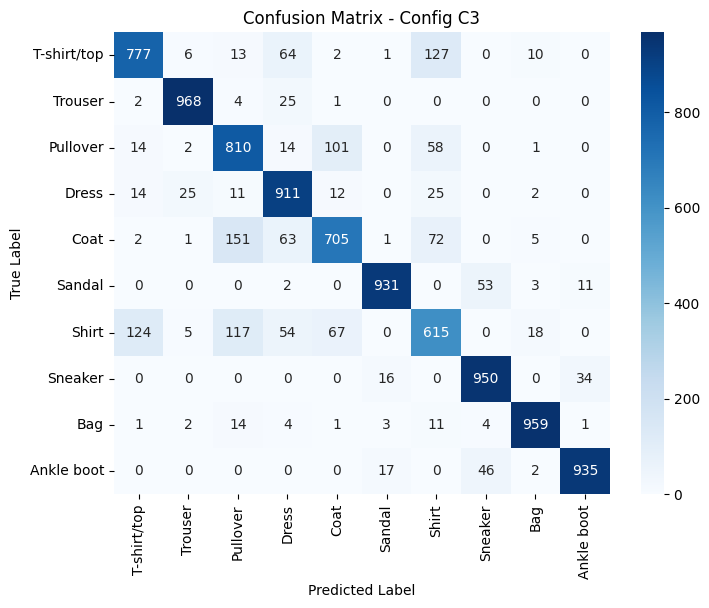

Training config C4...
Epoch 1, Loss: 0.7514
Epoch 2, Loss: 0.4934
Epoch 3, Loss: 0.4310
Epoch 4, Loss: 0.3972
Epoch 5, Loss: 0.3758
Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.67      0.76      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.76      0.79      0.77      1000
       Dress       0.83      0.92      0.87      1000
        Coat       0.82      0.64      0.72      1000
      Sandal       0.95      0.94      0.94      1000
       Shirt       0.54      0.73      0.62      1000
     Sneaker       0.91      0.94      0.92      1000
         Bag       0.97      0.95      0.96      1000
  Ankle boot       0.96      0.94      0.95      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



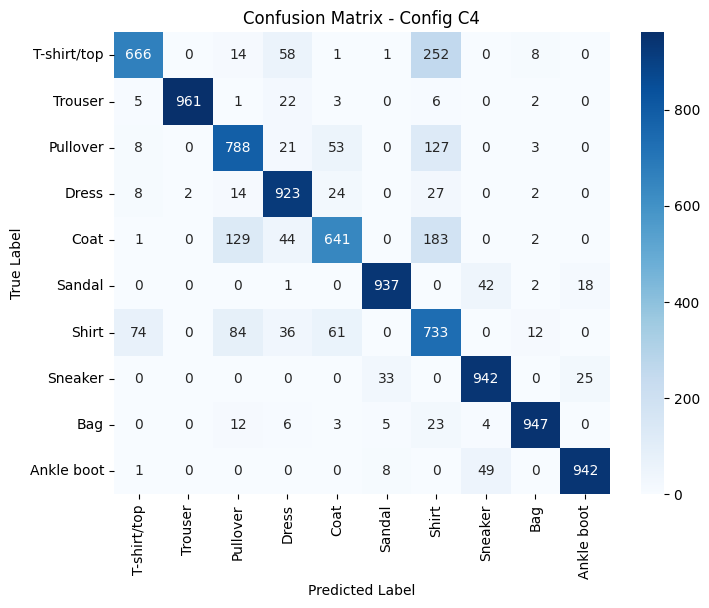

In [47]:
configs_vit = [
    {"name":"C1","depth":2,"emb_size":64,"patch_size":4,"use_cls_token":True},
    {"name":"C2","depth":4,"emb_size":128,"patch_size":4,"use_cls_token":True},
    {"name":"C3","depth":6,"emb_size":128,"patch_size":2,"use_cls_token":False},
    {"name":"C4","depth":8,"emb_size":256,"patch_size":8,"use_cls_token":True},
]

results = []

for cfg in configs_vit:
  print(f"Training config {cfg['name']}...")
  model = ViT(
      num_classes=10,
      emb_size=cfg['emb_size'],
      depth=cfg['depth'],
      patch_size=cfg['patch_size'],
      use_cls_token=cfg['use_cls_token']
  ).to(device)

  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
  criterion = nn.CrossEntropyLoss()

  for epoch in range(5):
      model.train()
      total_loss = 0
      for images, labels in train_loader:
          images, labels = images.to(device), labels.to(device)
          optimizer.zero_grad()
          loss = criterion(model(images), labels)
          loss.backward()
          optimizer.step()
          total_loss += loss.item()
      print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

  # --- Evaluation ---
  model.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          preds = torch.argmax(outputs, dim=1)
          all_preds.append(preds.cpu())
          all_labels.append(labels.cpu())

  y_pred = torch.cat(all_preds).numpy()
  y_true = torch.cat(all_labels).numpy()

  report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
  print("Classification Report:\n")
  print(classification_report(y_true, y_pred, target_names=class_names))

  config_metrics = {
      'Config' : cfg['name'],
      'Accuracy': (y_pred == y_true).mean()
  }

  for cls in class_names:
    config_metrics[f'Precision_{cls}'] = report_dict[cls]['precision']
    config_metrics[f'Recall_{cls}'] = report_dict[cls]['recall']
    config_metrics[f'F1_{cls}'] = report_dict[cls]['f1-score']
  results.append(config_metrics)

  acc = (y_pred == y_true).mean()
  results.append({"Config":cfg["name"], "Accuracy":acc})

  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
  plt.title(f"Confusion Matrix - Config {cfg['name']}")
  plt.ylabel("True Label")
  plt.xlabel("Predicted Label")
  plt.show()


In [48]:
df_results = pd.DataFrame(results)
df_results = df_results.drop_duplicates(subset='Config', keep='first')
df_results = df_results.reset_index(drop=True)
pd.set_option('display.max_columns', None)
# display(df_results)
df_results


,Config,Accuracy,Precision_T-shirt/top,Recall_T-shirt/top,F1_T-shirt/top,Precision_Trouser,Recall_Trouser,F1_Trouser,Precision_Pullover,Recall_Pullover,F1_Pullover,Precision_Dress,Recall_Dress,F1_Dress,Precision_Coat,Recall_Coat,F1_Coat,Precision_Sandal,Recall_Sandal,F1_Sandal,Precision_Shirt,Recall_Shirt,F1_Shirt,Precision_Sneaker,Recall_Sneaker,F1_Sneaker,Precision_Bag,Recall_Bag,F1_Bag,Precision_Ankle boot,Recall_Ankle boot,F1_Ankle boot
0,C1,0.8306,0.807574,0.789,0.798179,0.990526,0.941,0.965128,0.723077,0.705,0.713924,0.741463,0.912,0.817937,0.714008,0.734,0.723866,0.933943,0.919,0.926411,0.636364,0.532,0.579521,0.898785,0.888,0.893360,0.955645,0.948,0.951807,0.901923,0.938,0.919608
1,C2,0.8646,0.857955,0.755,0.803191,0.984663,0.963,0.973711,0.811870,0.725,0.765980,0.870206,0.885,0.877541,0.726488,0.842,0.779991,0.960204,0.941,0.950505,0.648415,0.675,0.661440,0.931480,0.938,0.934728,0.941691,0.969,0.955150,0.937992,0.953,0.945437
2,C3,0.8561,0.831906,0.777,0.803516,0.959366,0.968,0.963664,0.723214,0.810,0.764151,0.801231,0.911,0.852597,0.793026,0.705,0.746427,0.960784,0.931,0.945658,0.677313,0.615,0.644654,0.902184,0.950,0.925475,0.959000,0.959,0.959000,0.953109,0.935,0.943968
3,C4,0.8480,0.872870,0.666,0.755530,0.997923,0.961,0.979114,0.756238,0.788,0.771792,0.830783,0.923,0.874467,0.815522,0.641,0.717805,0.952236,0.937,0.944556,0.542561,0.733,0.623564,0.908390,0.942,0.924890,0.968303,0.947,0.957533,0.956345,0.942,0.949118


# 3.3. Time series

In this section we will use Transformers for multivariate time series forecasting. The synthetic time series from Assignment 2 will be used

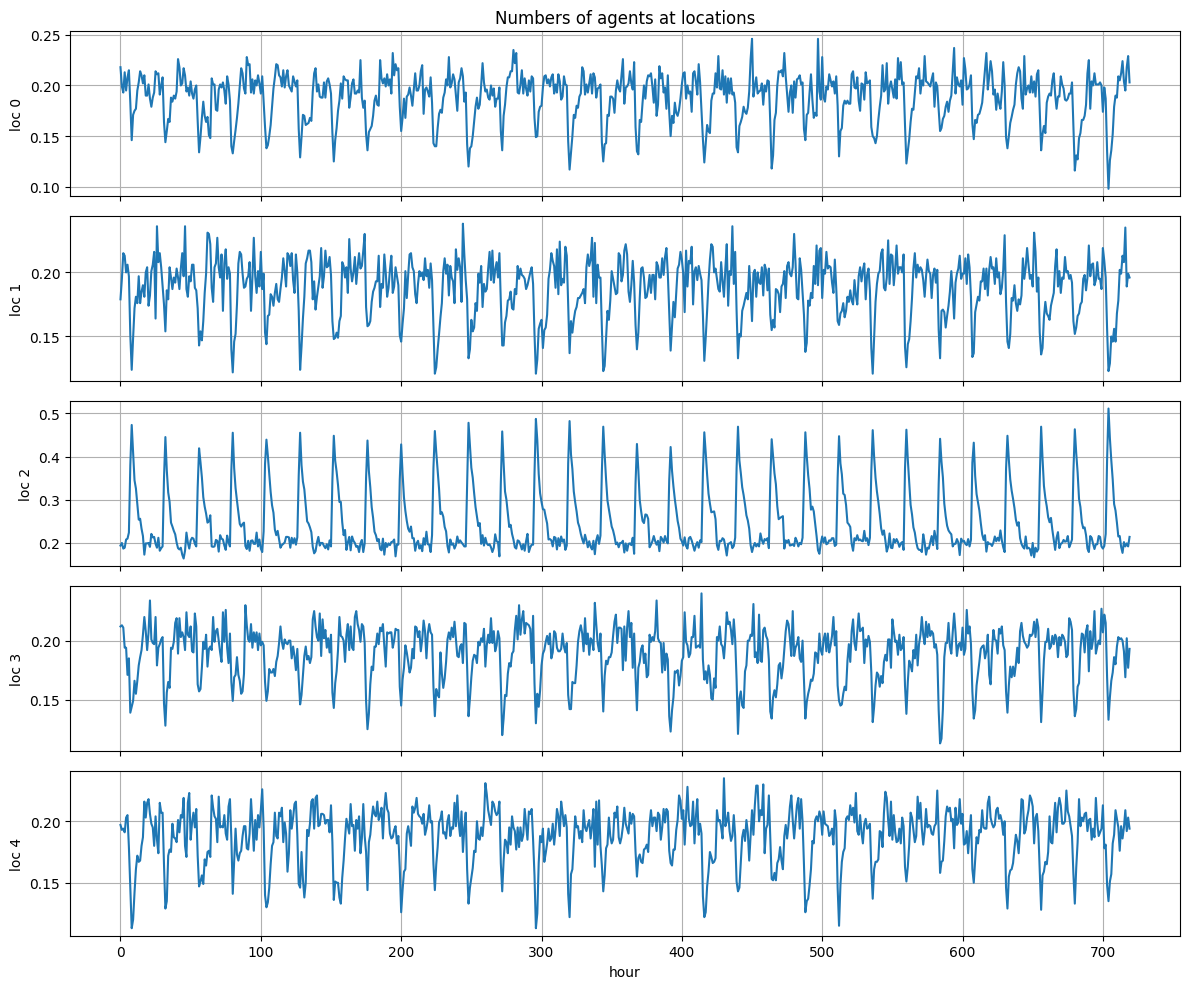

In [49]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- parameters ---
n_agents = 1000
n_locations = 5
center = 2
steps_per_day = 24
n_days = 30
T = steps_per_day * n_days

# --- parameters controlling  moves---
base_move_prob = 0.05
bias_to_center = 0.25
bias_to_home = 0.25
night_suppression = 0.2
random_variation = 0.05

# --- initiation of agnets ---
home = np.random.choice(n_locations, n_agents)
location = home.copy()
x = np.zeros((T, n_locations))

def hour_phase(hour):
    if 7 <= hour < 9:
        return 'morning'
    elif 9 <= hour < 17:
        return 'day'
    elif 17 <= hour < 19:
        return 'evening'
    else:
        return 'night'

# --- main sim loop ---
for t in range(T):
    hour = t % steps_per_day
    phase = hour_phase(hour)

    # basic transition matrix
    P = np.ones((n_locations, n_locations)) * base_move_prob
    np.fill_diagonal(P, 1 - base_move_prob * (n_locations - 1))

    if phase == 'morning':
        P[:, center] += bias_to_center
    elif phase == 'evening':
        for i in range(n_agents):
            P[location[i], home[i]] += bias_to_home
    elif phase == 'night':
        P = 1 - night_suppression + night_suppression * P

    # random perturbations
    P += random_variation * (np.random.rand(*P.shape) - 0.5)
    P = np.clip(P, 0, None)
    P /= P.sum(axis=1, keepdims=True)

    # updating agents locations
    new_locations = []
    for i in range(n_agents):
        loc = location[i]
        probs = P[loc]
        new_loc = np.random.choice(n_locations, p=probs)
        new_locations.append(new_loc)
    location = np.array(new_locations)

    # saving states (with normalization)
    for j in range(n_locations):
        x[t, j] = np.sum(location == j) / n_agents

# --- plots ---
fig, axes = plt.subplots(n_locations, 1, figsize=(12, 2*n_locations), sharex=True)

for j in range(n_locations):
    axes[j].plot(x[:, j], color='tab:blue')
    axes[j].set_ylabel(f"loc {j}")
    axes[j].grid(True)
    if j == 0:
        axes[j].set_title("Numbers of agents at locations")

axes[-1].set_xlabel("hour")
plt.tight_layout()
plt.show()


In [50]:
import pandas as pd

# assume, x has the shape (T, n_locations)
df = pd.DataFrame(x, columns=[f"loc_{j}" for j in range(n_locations)])
df.to_csv("population_timeseries.csv", index_label="t")
df.head()


,loc_0,loc_1,loc_2,loc_3,loc_4
0,0.218,0.179,0.194,0.212,0.197
1,0.199,0.195,0.200,0.213,0.193
2,0.193,0.215,0.187,0.211,0.194
3,0.213,0.213,0.189,0.194,0.191
4,0.195,0.200,0.208,0.194,0.203


As previous we will use 24 hours window (past values) to predict values one step ahead. A dataset containing observations $(x_i,y_i)$ where $x_i \in \mathbb{R}^{5 \times 24}$ and $y_i \in \mathbb{R}^{5}$ will be extracted from tthe time series.

In [51]:
import numpy as np

# parameters
window_size = 24  # use last 24 hours to predict one hour ahead
n_features = n_locations

# tworzymy X i y
X = []
y = []

for t in range(T - window_size):
    X.append(df.iloc[t:t+window_size].values)
    y.append(df.iloc[t+window_size].values)

X = np.array(X)  # shape: (samples, window_size, n_features)
y = np.array(y)  # shape: (samples, n_features)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (696, 24, 5)
y shape: (696, 5)


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

**Key point** the time series data must be scaled.

In [53]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Flatten time dimension for fitting (if your X is [samples, window, features])
X_train_2d = X_train.reshape(-1, X_train.shape[-1])
scaler_X.fit(X_train_2d)

# Scale y as well
scaler_y.fit(y_train)


,copy,True
,with_mean,True
,with_std,True


In [54]:
X_train_scaled = scaler_X.transform(X_train_2d).reshape(X_train.shape)
X_test_scaled  = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

y_train_scaled = scaler_y.transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)


## 3.3.1 TensorFlow implementation

**Key points**

* Use sin/cos positional encoding
* Dose not use class token. The last token in the sequence is used in prediction (or mean of token values - commented out `GlobalAveragPooling1D` or all token values)

In [55]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import metrics


# === Hyperparameters ===
window_size = 24
num_features = 5
d_model = 64
num_heads = 4
ff_dim = 128
num_layers = 2

# === Positional Encoding ===

class PositionalEncoding(layers.Layer):
    def __init__(self, maxlen, d_model):
        super().__init__()
        self.maxlen = maxlen
        self.d_model = d_model
        # prepare positional encoding only once (float32)
        pos = tf.cast(tf.range(self.maxlen)[:, tf.newaxis], tf.float32)          # (maxlen, 1)
        i = tf.cast(tf.range(self.d_model)[tf.newaxis, :], tf.float32)          # (1, d_model)
        # frequencies: 1 / (10000^(2*(i//2)/d_model))
        angle_rates = 1.0 / tf.pow(10000.0, (2.0 * tf.floor(i / 2.0)) / tf.cast(self.d_model, tf.float32))
        angle_rads = pos * angle_rates  # (maxlen, d_model)

        # sin for even indexes, cos for odd
        sines = tf.sin(angle_rads[:, 0::2])    # (maxlen, d_model/2)
        cosines = tf.cos(angle_rads[:, 1::2])  # (maxlen, d_model/2)

        # arange as [sin0, cos0, sin1, cos1, ...]
        pos_encoding = tf.reshape(tf.stack([sines, cosines], axis=-1), (self.maxlen, self.d_model))
        pos_encoding = pos_encoding[tf.newaxis, ...]  # (1, maxlen, d_model)
        self.pos_encoding = tf.cast(pos_encoding, tf.float32)

    def call(self, x):
        # x: (batch, seq_len, d_model_in)
        seq_len = tf.shape(x)[1]
        # cast position dtype p dtype of input and add
        return x + tf.cast(self.pos_encoding[:, :seq_len, :], x.dtype)

# === Transformer Block ===
def transformer_block(inputs):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(inputs, inputs)
    attn_output = layers.Dropout(0.1)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attn_output)

    ffn = tf.keras.Sequential([
        layers.Dense(ff_dim, activation='relu'),
        layers.Dense(d_model),
    ])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(0.1)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

# === Full Model ===
inputs = layers.Input(shape=(window_size, num_features))

# Project features to model dimension
x = layers.Dense(d_model)(inputs)
x = PositionalEncoding(window_size, d_model)(x)

# Apply N transformer layers
for _ in range(num_layers):
    x = transformer_block(x)

# Use the last token
last = layers.Lambda(lambda t: t[:, -1, :])(x)
outputs = layers.Dense(num_features)(last)

# Or pool across the time dimension
# x = layers.GlobalAveragePooling1D()(x)
# outputs = layers.Dense(num_features)(x)


# Or use the whole sequence
# x = layers.Flatten()(x)
# outputs = layers.Dense(num_features)(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=[
                metrics.MeanAbsoluteError(name='mae'),
                metrics.RootMeanSquaredError(name='rmse'),
                metrics.R2Score(name='r2')])

model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 24, 64)    │        384 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 24, 64)    │          0 │ dense_26[0][0]    │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     66,368 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 24, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 24, 64)    │          0 │ positional_encod… │
│                     │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_17[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 24, 64)    │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 24, 64)    │          0 │ sequential_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_18[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 24, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_19[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 24, 64)    │     16,576 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 24, 64)    │          0 │ sequential_2[0][… │
│ (Dropout)           │                   │            │                 

 Total params: 167,109 (652.77 KB)

 Trainable params: 167,109 (652.77 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
hist = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=50,
    batch_size=32
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.9062 - mae: 0.7310 - r2: 0.0938 - rmse: 0.9520 - val_loss: 0.5690 - val_mae: 0.5387 - val_r2: 0.4440 - val_rmse: 0.7543
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5903 - mae: 0.5843 - r2: 0.4097 - rmse: 0.7683 - val_loss: 0.5048 - val_mae: 0.5280 - val_r2: 0.5059 - val_rmse: 0.7105
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5192 - mae: 0.5525 - r2: 0.4808 - rmse: 0.7205 - val_loss: 0.4371 - val_mae: 0.5006 - val_r2: 0.5682 - val_rmse: 0.6611
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4135 - mae: 0.5046 - r2: 0.5865 - rmse: 0.6430 - val_loss: 0.3001 - val_mae: 0.4280 - val_r2: 0.7071 - val_rmse: 0.5478
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3551 - mae: 0.4670 - r2: 0.6449 - rmse: 0.5959 - val_loss: 0.3004 - val_mae: 0.4169 - val_r2: 0.7097 - val_rmse: 0.5480
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3266 - mae: 0.4498 - r2: 0.6734 - rmse:

In [57]:
loss, mae,rmse,r2 = model.evaluate(X_test_scaled, y_test_scaled)
print(f"Test MAE: {mae} Test RMSE: {rmse} Test r2 {r2}" )


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3250 - mae: 0.4331 - r2: 0.6806 - rmse: 0.5701 
Test MAE: 0.4331148564815521 Test RMSE: 0.5701258778572083 Test r2 0.6805561184883118


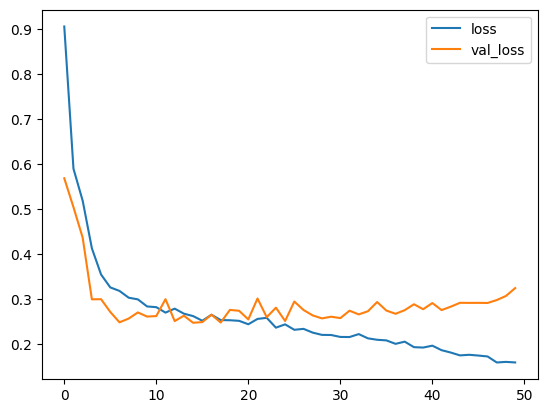

In [58]:
plt.plot(hist.history['loss'], label='loss')
plt.plot(hist.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [59]:
hist.history.keys()

dict_keys(['loss', 'mae', 'r2', 'rmse', 'val_loss', 'val_mae', 'val_r2', 'val_rmse'])

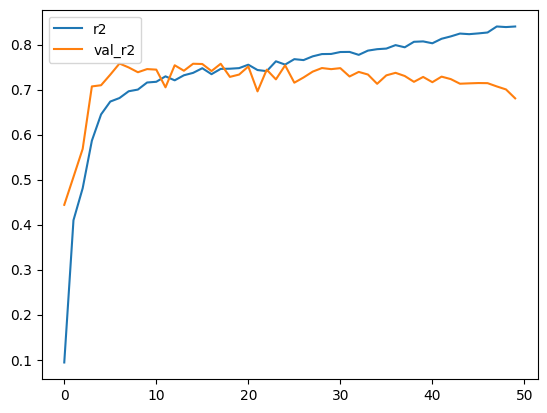

In [60]:
plt.plot(hist.history['r2'], label='r2')
plt.plot(hist.history['val_r2'], label='val_r2')
plt.legend()
plt.show()

In [61]:
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

from sklearn.metrics import r2_score, mean_squared_error
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
R²: 0.6805560927886173
MSE: 0.0002176815077146247


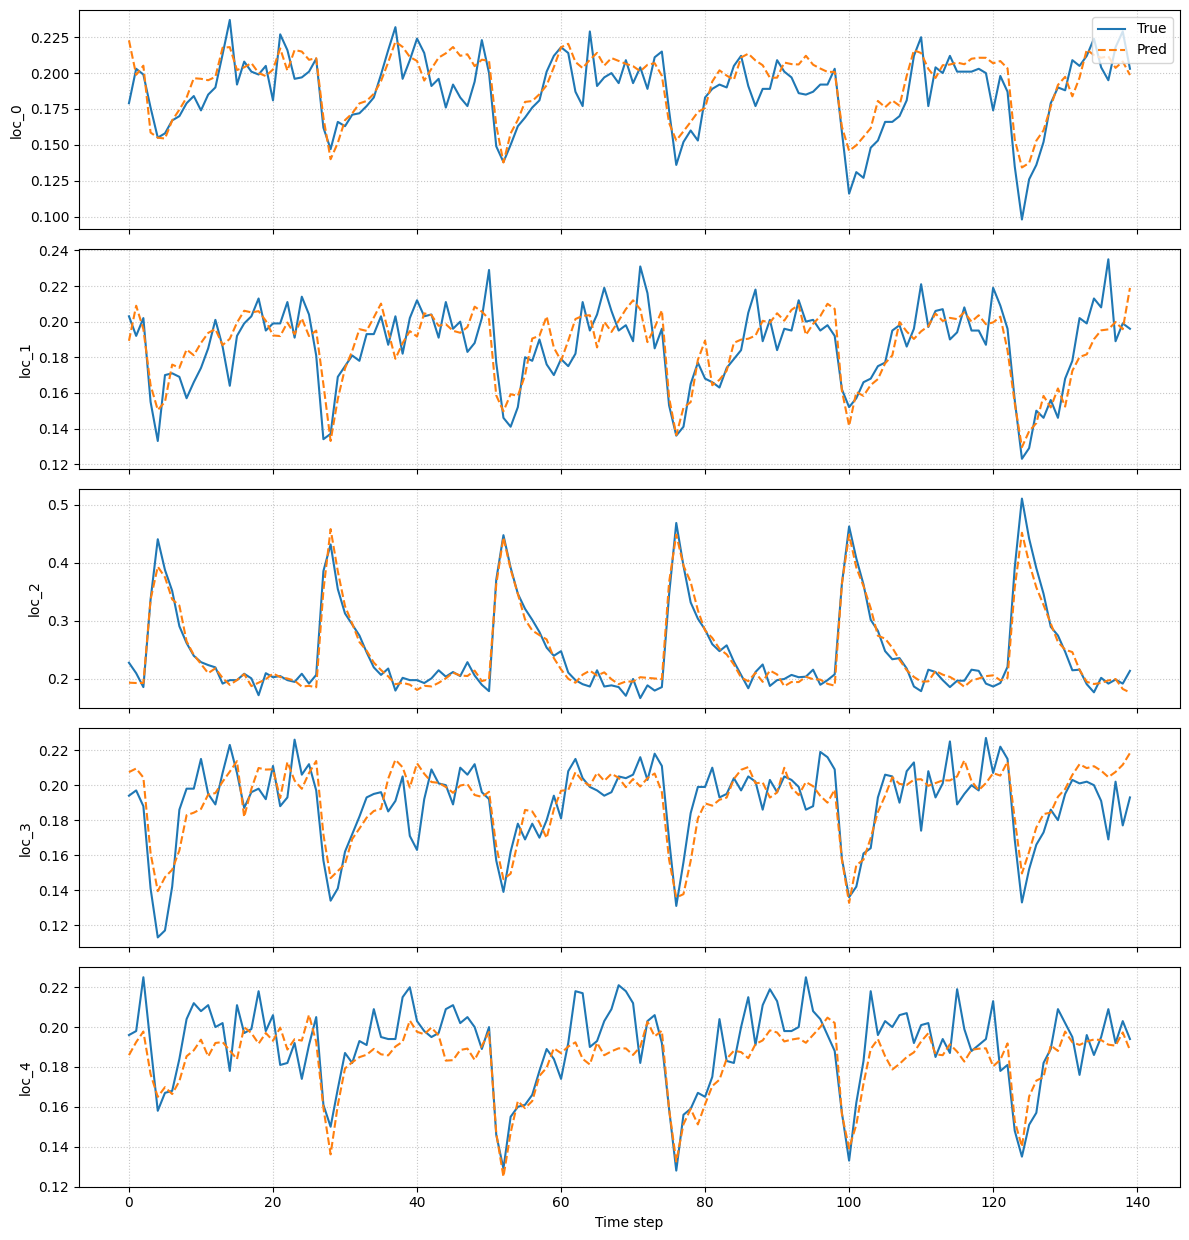

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# assume you already have:
# y_test: shape (N, 5)
# y_pred: shape (N, 5)

n_features = y_test.shape[1]
timesteps = np.arange(len(y_test))

fig, axes = plt.subplots(n_features, 1, figsize=(12, 2.5 * n_features), sharex=True)

for i in range(n_features):
    ax = axes[i]
    ax.plot(timesteps, y_test[:, i], label='True', linewidth=1.5)
    ax.plot(timesteps, y_pred[:, i], label='Pred', linestyle='--', linewidth=1.5)
    ax.set_ylabel(f'loc_{i}')
    ax.grid(True, linestyle=':', alpha=0.7)
    if i == 0:
        ax.legend(loc='upper right')
    if i == n_features - 1:
        ax.set_xlabel('Time step')

plt.tight_layout()
plt.show()


## 3.3.2 PyTorch implementation

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# --- Configurable hyperparameters controlling model complexity ---
d_model = 64          # embedding dimension
num_heads = 4         # number of attention heads
num_layers = 4        # number of transformer encoder layers
ff_dim = 128          # feed-forward hidden dimension
dropout = 0.1         # dropout rate
batch_size = 32
epochs = 50
lr = 1e-3

# --- Prepare data ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val = torch.tensor(X_test_scaled, dtype=torch.float32)
y_val = torch.tensor(y_test_scaled, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)


In [64]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model, n_heads, n_layers, ff_dim, dropout=0.1):
        super().__init__()

        # Project input features (e.g. 5 → 64)
        self.input_proj = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_encoding = self._generate_pos_encoding(500, d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Regression head
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, input_dim)
        )

    def _generate_pos_encoding(self, max_len, d_model):
        """Precompute sinusoidal positional encodings"""
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        return pe

    def forward(self, x):
        seq_len = x.size(1)
        x = self.input_proj(x) + self.pos_encoding[:, :seq_len, :].to(x.device)
        x = self.transformer(x)
        x = x.mean(dim=1)  # Global average pooling over sequence
        return self.head(x)


In [65]:
model = TimeSeriesTransformer(
    input_dim=X_train.shape[2],
    d_model=d_model,
    n_heads=num_heads,
    n_layers=num_layers,
    ff_dim=ff_dim,
    dropout=dropout
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

def r2_score(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * Xb.size(0)

    model.eval()
    val_loss, val_r2 = 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            preds = model(Xb).squeeze()
            val_loss += criterion(preds, yb).item() * Xb.size(0)
            val_r2 += r2_score(yb, preds).item() * Xb.size(0)

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    val_r2 /= len(val_loader.dataset)

    print(f"Epoch {epoch+1:02d} | Train loss: {train_loss:.4f} | "
          f"Val loss: {val_loss:.4f} | Val R2: {val_r2:.4f}")


Epoch 01 | Train loss: 0.9425 | Val loss: 0.7142 | Val R2: 0.3211
Epoch 02 | Train loss: 0.5187 | Val loss: 0.4601 | Val R2: 0.5247
Epoch 03 | Train loss: 0.3774 | Val loss: 0.3686 | Val R2: 0.6128
Epoch 04 | Train loss: 0.3487 | Val loss: 0.3617 | Val R2: 0.6283
Epoch 05 | Train loss: 0.3545 | Val loss: 0.4145 | Val R2: 0.5803
Epoch 06 | Train loss: 0.3441 | Val loss: 0.3509 | Val R2: 0.6375
Epoch 07 | Train loss: 0.3378 | Val loss: 0.3566 | Val R2: 0.6310
Epoch 08 | Train loss: 0.3328 | Val loss: 0.3624 | Val R2: 0.6270
Epoch 09 | Train loss: 0.3222 | Val loss: 0.3539 | Val R2: 0.6338
Epoch 10 | Train loss: 0.3067 | Val loss: 0.3644 | Val R2: 0.6272
Epoch 11 | Train loss: 0.3068 | Val loss: 0.3583 | Val R2: 0.6297
Epoch 12 | Train loss: 0.3058 | Val loss: 0.3362 | Val R2: 0.6468
Epoch 13 | Train loss: 0.3063 | Val loss: 0.3460 | Val R2: 0.6395
Epoch 14 | Train loss: 0.2739 | Val loss: 0.3527 | Val R2: 0.6381
Epoch 15 | Train loss: 0.2659 | Val loss: 0.3401 | Val R2: 0.6547
Epoch 16 |

In [66]:
import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# --- tryb ewaluacji ---
model.eval()

# --- zbieramy predykcje ---
y_true_list = []
y_pred_list = []

with torch.no_grad():
    for Xb, yb in val_loader:
        Xb = Xb.to(device)
        preds = model(Xb)
        y_true_list.append(yb.cpu().numpy())
        y_pred_list.append(preds.cpu().numpy())

# --- składamy w jeden array ---
y_true_scaled = np.vstack(y_true_list)
y_pred_scaled = np.vstack(y_pred_list)

# --- odwrotna transformacja ---
y_true = scaler_y.inverse_transform(y_true_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# --- metryki ---
r2 = r2_score(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)

print(f"R²: {r2:.4f}")
print(f"MSE: {mse:.6f}")


R²: 0.6395
MSE: 0.000276


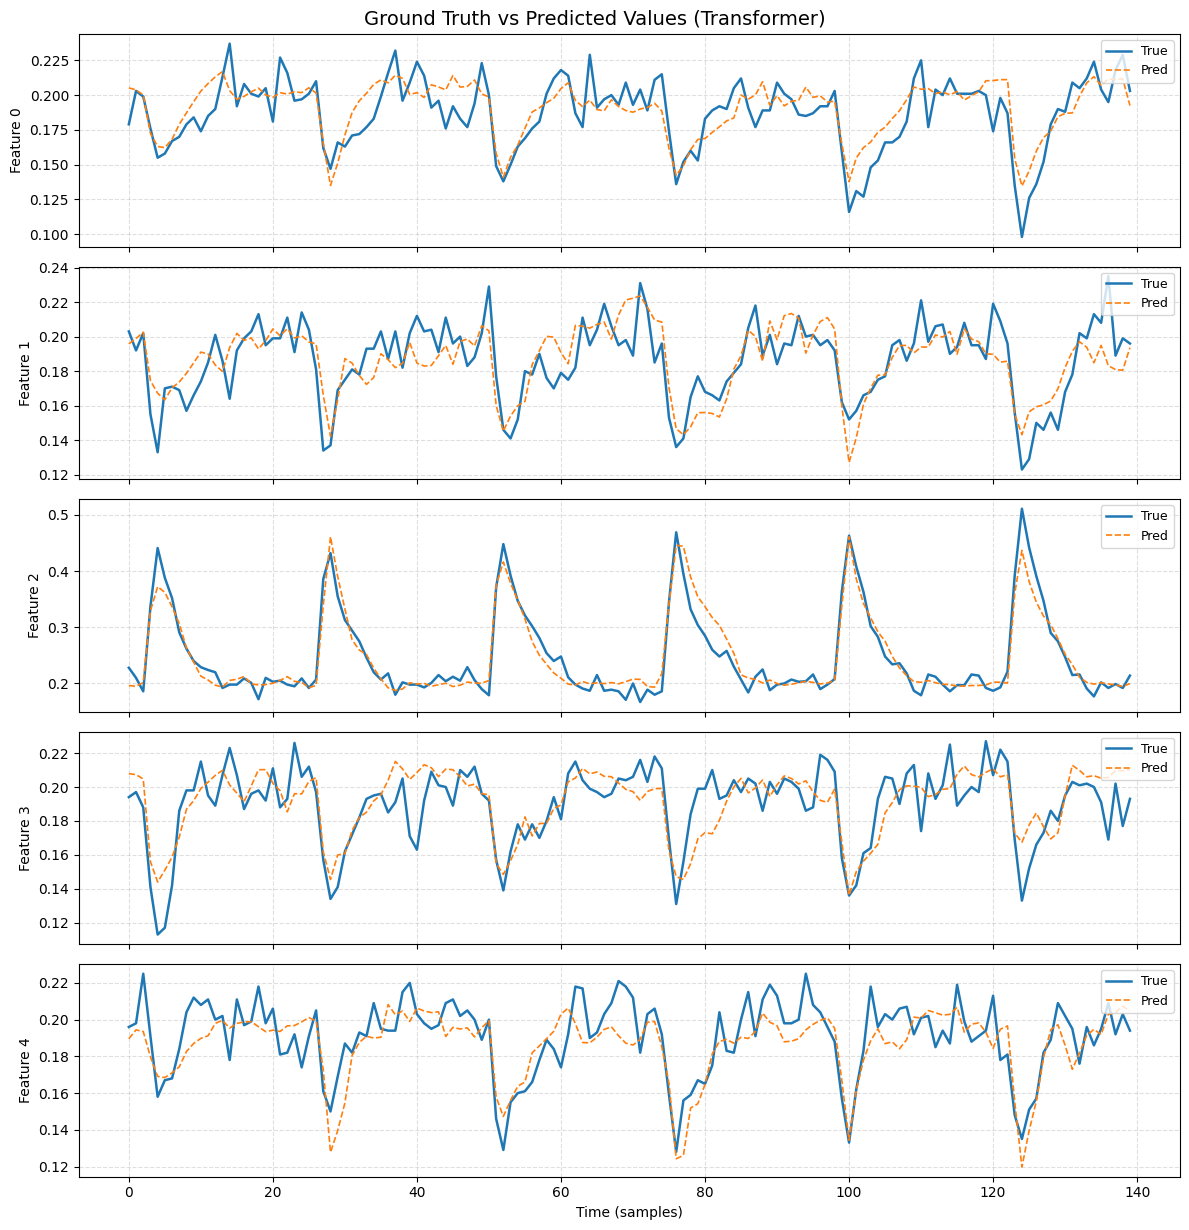

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Assume y_true and y_pred are numpy arrays of shape (n_samples, 5)
n_features = y_true.shape[1]
time = np.arange(len(y_true))  # x-axis index (could be timestamps if you have them)

fig, axes = plt.subplots(n_features, 1, figsize=(12, 2.5 * n_features), sharex=True)

for i in range(n_features):
    ax = axes[i]
    ax.plot(time, y_true[:, i], label="True", lw=1.8)
    ax.plot(time, y_pred[:, i], label="Pred", lw=1.2, linestyle='--')
    ax.set_ylabel(f"Feature {i}")
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Time (samples)")
fig.suptitle("Ground Truth vs Predicted Values (Transformer)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


## 3.3.3 **TODO**

Test 6-8 configurations for various:
* window sizes
* embedding dimensions
* numbers of attention heads
* numbers of transformers layers
* feed-forward network size (dimensfionality of the internal dense layer inside each Transformer block)

Give summary results in a table. Include parameters and  regression scores. Add selected plots (e.g. for the best and worst results).



In [68]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model, n_heads, n_layers, ff_dim, dropout=0.1):
        super().__init__()

        # Project input features (e.g. 5 → 64)
        self.input_proj = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_encoding = self._generate_pos_encoding(500, d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Regression head
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, input_dim)
        )

    def _generate_pos_encoding(self, max_len, d_model):
        """Precompute sinusoidal positional encodings"""
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        return pe

    def forward(self, x):
        seq_len = x.size(1)
        x = self.input_proj(x) + self.pos_encoding[:, :seq_len, :].to(x.device)
        x = self.transformer(x)
        x = x.mean(dim=1)
        # x = x.mean(dim=1)  # Global average pooling over sequence
        return self.head(x)


In [69]:
def plot_results(y_true, y_pred, title):
    n_features = y_true.shape[1]
    time = np.arange(len(y_true))

    fig, axes = plt.subplots(n_features, 1, figsize=(12, 2.5 * n_features), sharex=True)

    for i in range(n_features):
        ax = axes[i]
        ax.plot(time, y_true[:, i], label="True", lw=1.8)
        ax.plot(time, y_pred[:, i], label="Pred", lw=1.2, linestyle="--")
        ax.set_ylabel(f"Feature {i}")
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(loc="upper right", fontsize=9)
    axes[-1].set_xlabel("Time (samples)")
    fig.suptitle(title, fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()


--- Running config: {'name': 'C1', 'window': 24, 'd_model': 32, 'heads': 2, 'layers': 2, 'ff': 64} ---
Epoch 01 | Train loss: 0.9883 | Val loss: 0.9624 | Val R2: 0.0048
Epoch 02 | Train loss: 0.7692 | Val loss: 0.5754 | Val R2: 0.3344
Epoch 03 | Train loss: 0.5014 | Val loss: 0.3770 | Val R2: 0.5646
Epoch 04 | Train loss: 0.4039 | Val loss: 0.3578 | Val R2: 0.5488
Epoch 05 | Train loss: 0.3836 | Val loss: 0.3504 | Val R2: 0.5911
Epoch 06 | Train loss: 0.3682 | Val loss: 0.3690 | Val R2: 0.5601
Epoch 07 | Train loss: 0.3602 | Val loss: 0.3292 | Val R2: 0.5981
Epoch 08 | Train loss: 0.3489 | Val loss: 0.3280 | Val R2: 0.6083
Epoch 09 | Train loss: 0.3401 | Val loss: 0.3263 | Val R2: 0.6098
Epoch 10 | Train loss: 0.3331 | Val loss: 0.3110 | Val R2: 0.6158
Epoch 11 | Train loss: 0.3189 | Val loss: 0.3105 | Val R2: 0.6189
Epoch 12 | Train loss: 0.3204 | Val loss: 0.3150 | Val R2: 0.6200
Epoch 13 | Train loss: 0.3061 | Val loss: 0.2983 | Val R2: 0.6319
Epoch 14 | Train loss: 0.3038 | Val lo

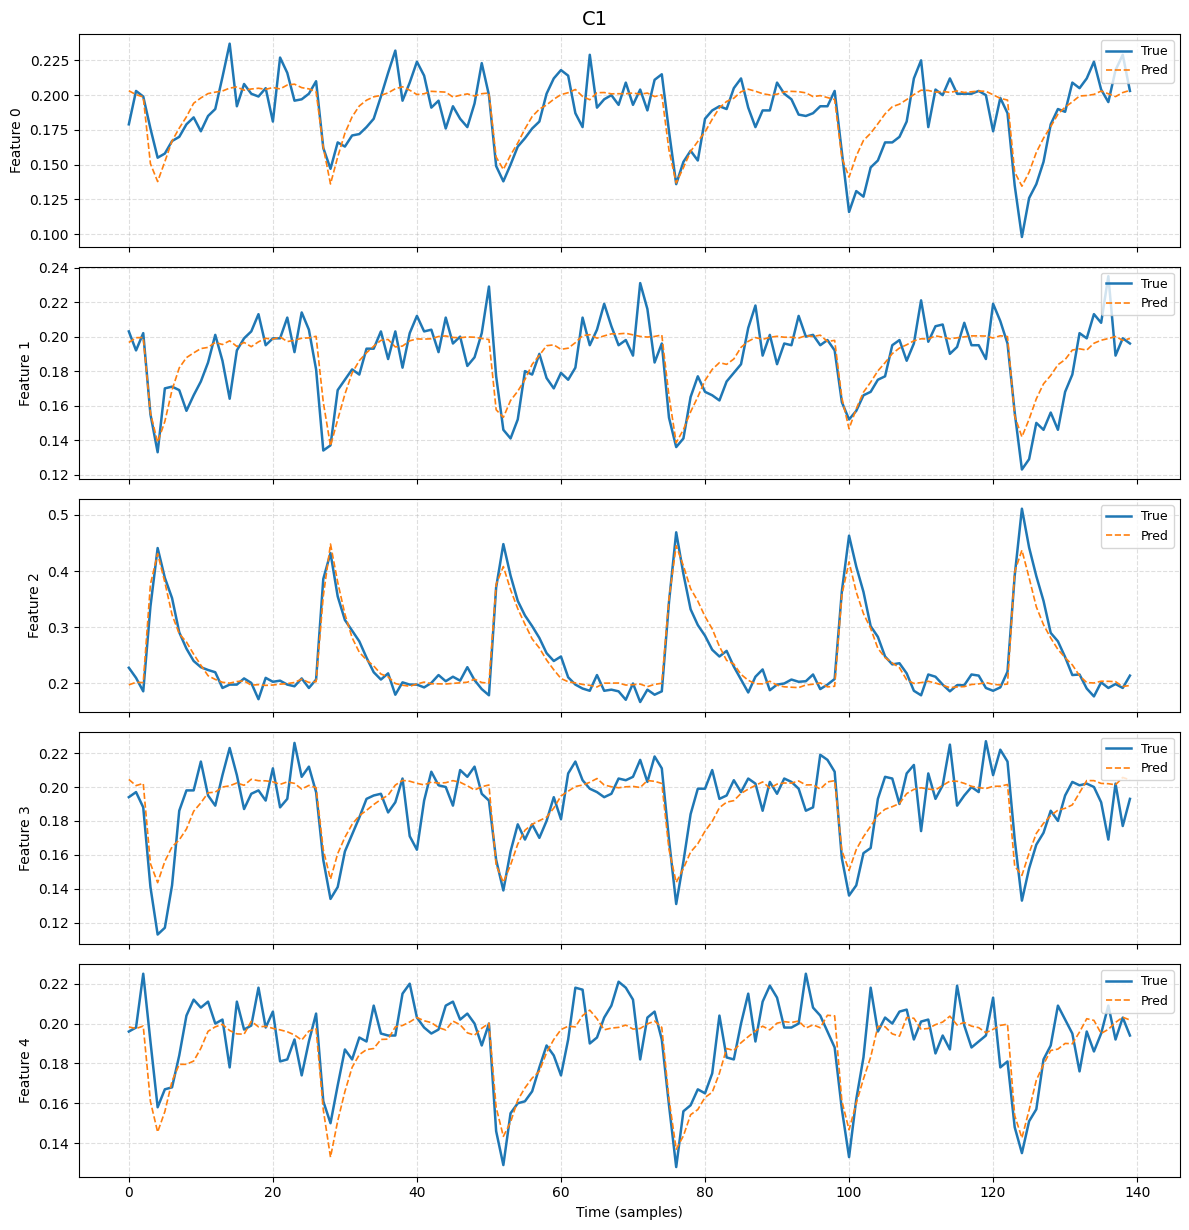

0.098000005 0.511
0.13293837 0.44813645

--- Running config: {'name': 'C2', 'window': 50, 'd_model': 64, 'heads': 4, 'layers': 4, 'ff': 128} ---
Epoch 01 | Train loss: 1.0127 | Val loss: 0.9330 | Val R2: -0.2525
Epoch 02 | Train loss: 0.6722 | Val loss: 0.4535 | Val R2: 0.4437
Epoch 03 | Train loss: 0.5174 | Val loss: 0.3812 | Val R2: 0.5223
Epoch 04 | Train loss: 0.4668 | Val loss: 0.4204 | Val R2: 0.4651
Epoch 05 | Train loss: 0.4049 | Val loss: 0.3740 | Val R2: 0.5308
Epoch 06 | Train loss: 0.3681 | Val loss: 0.3224 | Val R2: 0.5861
Epoch 07 | Train loss: 0.3542 | Val loss: 0.3110 | Val R2: 0.5912
Epoch 08 | Train loss: 0.3523 | Val loss: 0.3719 | Val R2: 0.5342
Epoch 09 | Train loss: 0.3333 | Val loss: 0.3009 | Val R2: 0.6167
Epoch 10 | Train loss: 0.3296 | Val loss: 0.2979 | Val R2: 0.6159
Epoch 11 | Train loss: 0.3245 | Val loss: 0.3394 | Val R2: 0.5856
Epoch 12 | Train loss: 0.3251 | Val loss: 0.3164 | Val R2: 0.5992
Epoch 13 | Train loss: 0.3252 | Val loss: 0.3337 | Val R2: 0.5

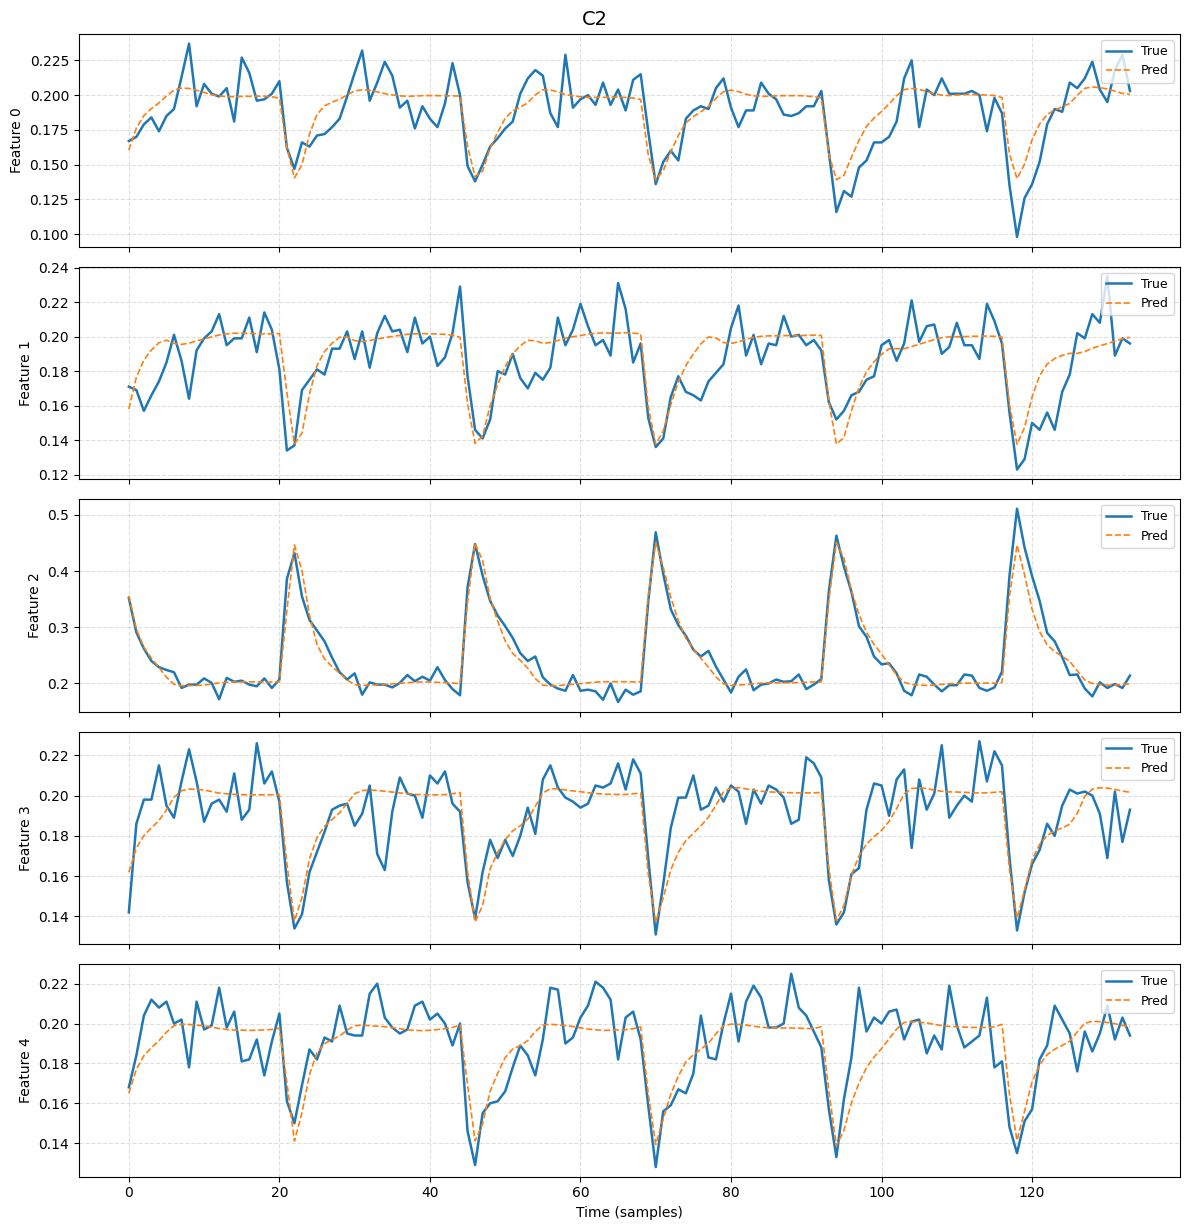

0.098 0.511
0.13722284 0.4509143

--- Running config: {'name': 'C3', 'window': 12, 'd_model': 128, 'heads': 8, 'layers': 4, 'ff': 256} ---
Epoch 01 | Train loss: 0.8350 | Val loss: 0.6057 | Val R2: 0.4037
Epoch 02 | Train loss: 0.4957 | Val loss: 0.4869 | Val R2: 0.5100
Epoch 03 | Train loss: 0.4480 | Val loss: 0.4332 | Val R2: 0.5396
Epoch 04 | Train loss: 0.4332 | Val loss: 0.4490 | Val R2: 0.5411
Epoch 05 | Train loss: 0.4226 | Val loss: 0.5295 | Val R2: 0.4490
Epoch 06 | Train loss: 0.4337 | Val loss: 0.4772 | Val R2: 0.4900
Epoch 07 | Train loss: 0.4490 | Val loss: 0.4373 | Val R2: 0.5451
Epoch 08 | Train loss: 0.4147 | Val loss: 0.4450 | Val R2: 0.5418
Epoch 09 | Train loss: 0.4340 | Val loss: 0.4460 | Val R2: 0.5305
Epoch 10 | Train loss: 0.3933 | Val loss: 0.4363 | Val R2: 0.5460
Epoch 11 | Train loss: 0.3859 | Val loss: 0.4686 | Val R2: 0.5044
Epoch 12 | Train loss: 0.3457 | Val loss: 0.5286 | Val R2: 0.4377
Epoch 13 | Train loss: 0.3610 | Val loss: 0.4389 | Val R2: 0.5410
Epo

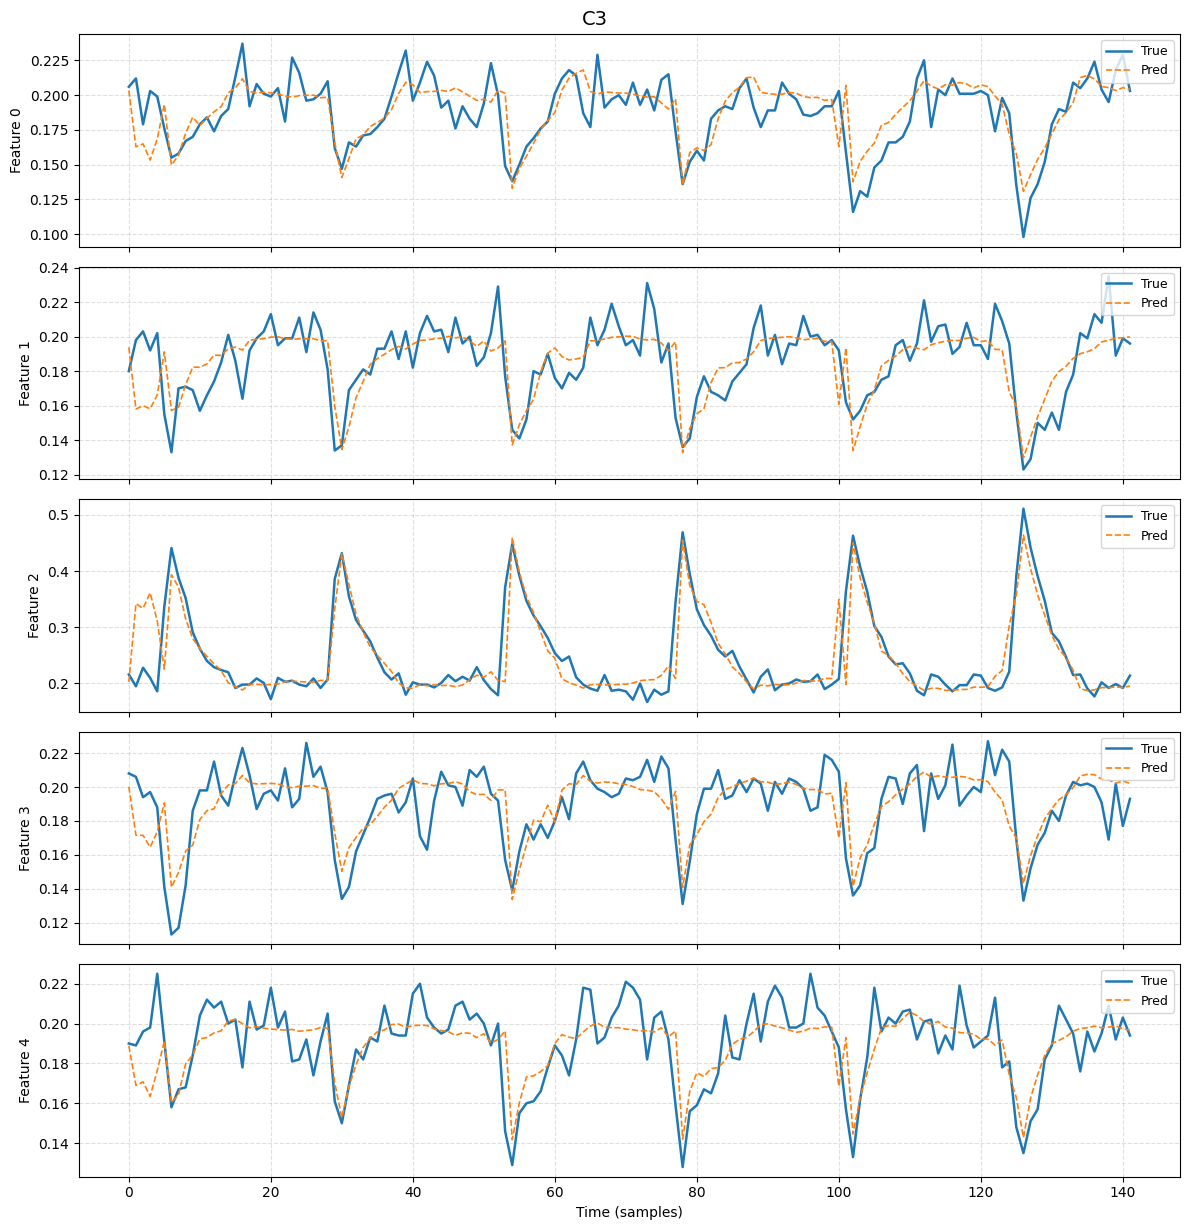

0.098 0.511
0.12977841 0.46418095

--- Running config: {'name': 'C4', 'window': 4, 'd_model': 64, 'heads': 8, 'layers': 6, 'ff': 256} ---
Epoch 01 | Train loss: 0.7999 | Val loss: 0.7035 | Val R2: 0.2491
Epoch 02 | Train loss: 0.5988 | Val loss: 0.4925 | Val R2: 0.4852
Epoch 03 | Train loss: 0.4806 | Val loss: 0.4385 | Val R2: 0.5275
Epoch 04 | Train loss: 0.4563 | Val loss: 0.4586 | Val R2: 0.5104
Epoch 05 | Train loss: 0.4387 | Val loss: 0.4376 | Val R2: 0.5134
Epoch 06 | Train loss: 0.4332 | Val loss: 0.4200 | Val R2: 0.5369
Epoch 07 | Train loss: 0.4117 | Val loss: 0.4096 | Val R2: 0.5487
Epoch 08 | Train loss: 0.4089 | Val loss: 0.4167 | Val R2: 0.5461
Epoch 09 | Train loss: 0.4023 | Val loss: 0.3947 | Val R2: 0.5690
Epoch 10 | Train loss: 0.4016 | Val loss: 0.4174 | Val R2: 0.5461
Epoch 11 | Train loss: 0.3961 | Val loss: 0.4015 | Val R2: 0.5630
Epoch 12 | Train loss: 0.3912 | Val loss: 0.4197 | Val R2: 0.5447
Epoch 13 | Train loss: 0.3941 | Val loss: 0.4048 | Val R2: 0.5556
Epoc

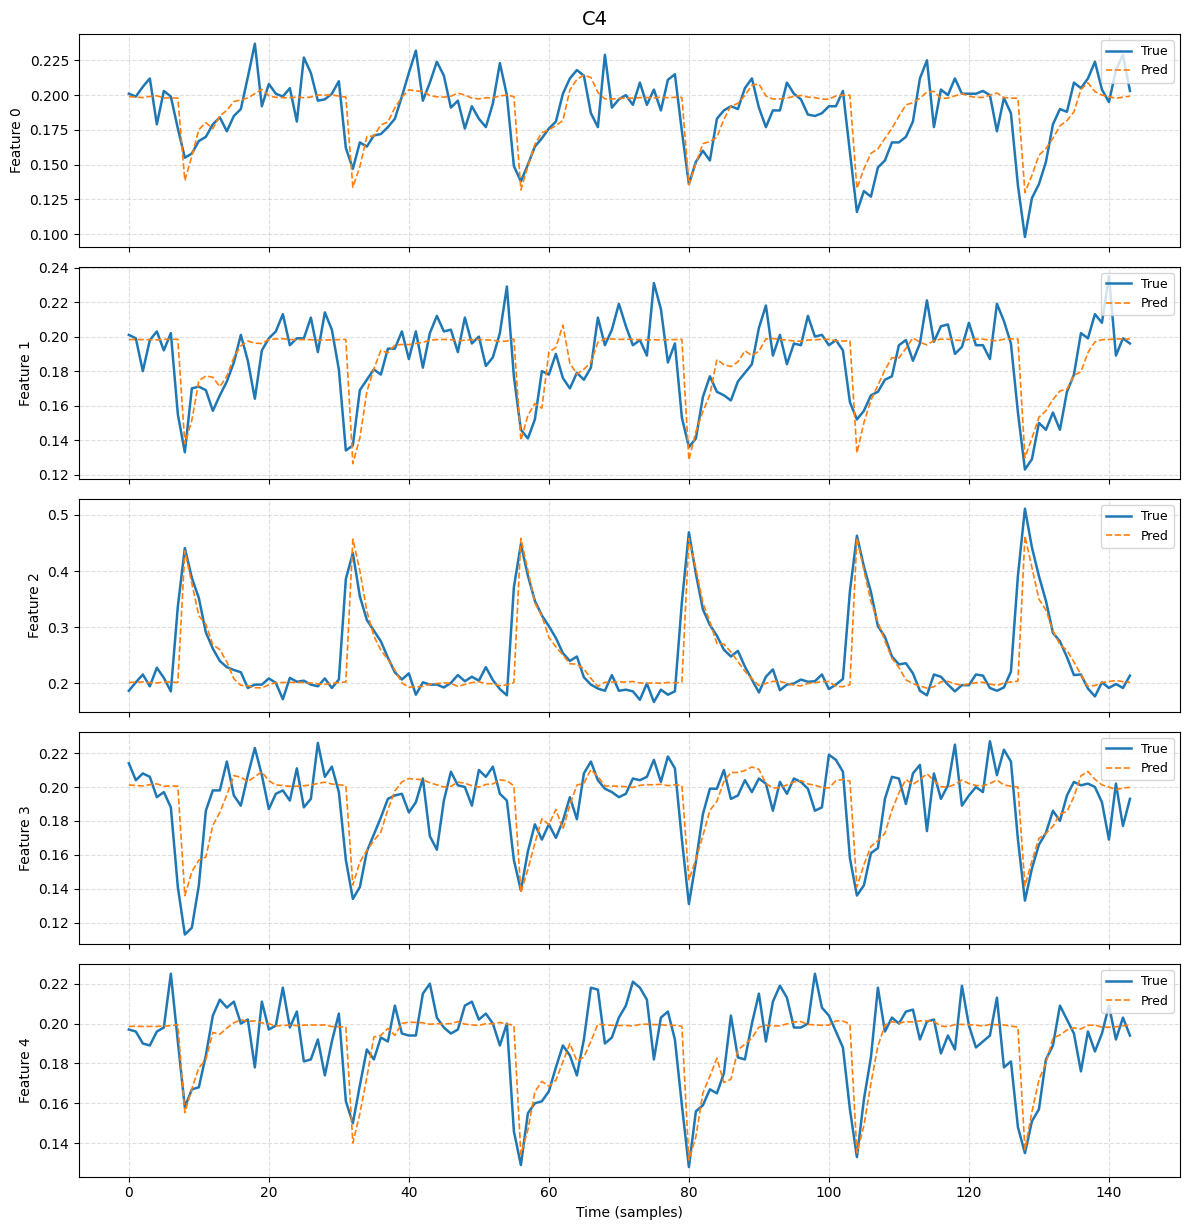

0.098 0.511
0.12636758 0.46236217

--- Running config: {'name': 'C5', 'window': 32, 'd_model': 128, 'heads': 4, 'layers': 2, 'ff': 256} ---
Epoch 01 | Train loss: 1.0222 | Val loss: 1.0486 | Val R2: -0.1659
Epoch 02 | Train loss: 0.7222 | Val loss: 0.4669 | Val R2: 0.4378
Epoch 03 | Train loss: 0.4549 | Val loss: 0.3644 | Val R2: 0.5718
Epoch 04 | Train loss: 0.3765 | Val loss: 0.3548 | Val R2: 0.5805
Epoch 05 | Train loss: 0.3723 | Val loss: 0.3650 | Val R2: 0.5694
Epoch 06 | Train loss: 0.3690 | Val loss: 0.3355 | Val R2: 0.5844
Epoch 07 | Train loss: 0.3600 | Val loss: 0.3208 | Val R2: 0.5918
Epoch 08 | Train loss: 0.3326 | Val loss: 0.3290 | Val R2: 0.6049
Epoch 09 | Train loss: 0.3451 | Val loss: 0.3381 | Val R2: 0.5987
Epoch 10 | Train loss: 0.3251 | Val loss: 0.3358 | Val R2: 0.5955
Epoch 11 | Train loss: 0.3235 | Val loss: 0.3149 | Val R2: 0.5892
Epoch 12 | Train loss: 0.3246 | Val loss: 0.3255 | Val R2: 0.6093
Epoch 13 | Train loss: 0.3132 | Val loss: 0.3154 | Val R2: 0.5974
E

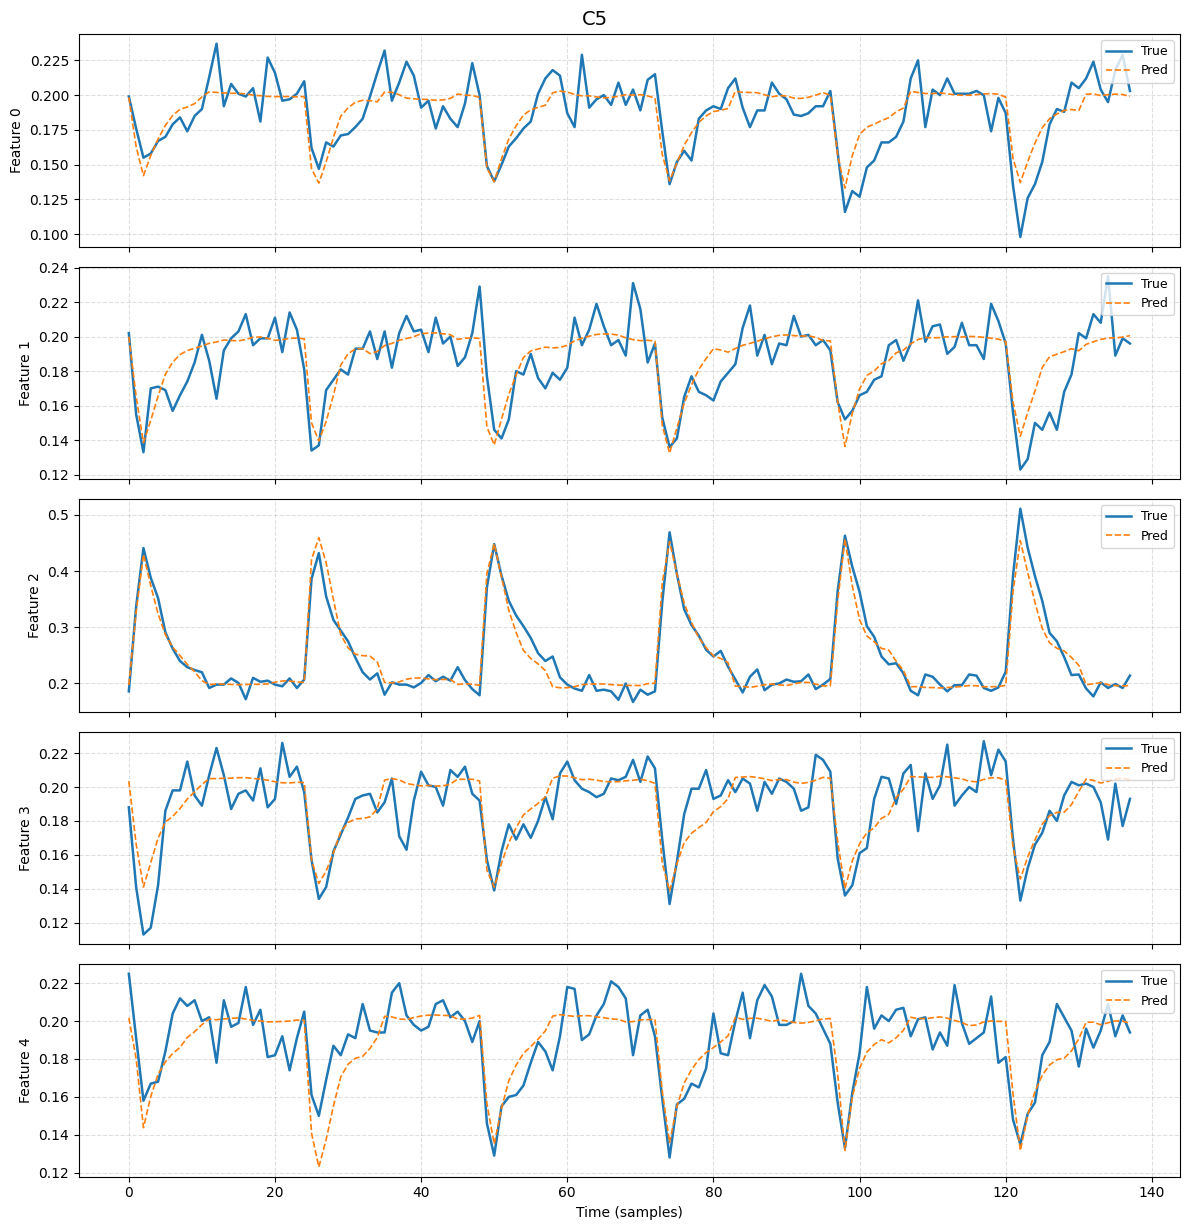

0.098000005 0.511
0.12296309 0.45943788

--- Running config: {'name': 'C6', 'window': 40, 'd_model': 128, 'heads': 8, 'layers': 6, 'ff': 64} ---
Epoch 01 | Train loss: 0.9799 | Val loss: 0.8367 | Val R2: 0.0172
Epoch 02 | Train loss: 0.6675 | Val loss: 0.4720 | Val R2: 0.4461
Epoch 03 | Train loss: 0.5233 | Val loss: 0.4295 | Val R2: 0.5261
Epoch 04 | Train loss: 0.4127 | Val loss: 0.3598 | Val R2: 0.5580
Epoch 05 | Train loss: 0.3444 | Val loss: 0.3367 | Val R2: 0.6034
Epoch 06 | Train loss: 0.3417 | Val loss: 0.3388 | Val R2: 0.5870
Epoch 07 | Train loss: 0.3338 | Val loss: 0.3458 | Val R2: 0.5835
Epoch 08 | Train loss: 0.3255 | Val loss: 0.3466 | Val R2: 0.5828
Epoch 09 | Train loss: 0.3246 | Val loss: 0.3405 | Val R2: 0.5994
Epoch 10 | Train loss: 0.3201 | Val loss: 0.3174 | Val R2: 0.6088
Epoch 11 | Train loss: 0.3129 | Val loss: 0.3656 | Val R2: 0.5698
Epoch 12 | Train loss: 0.3255 | Val loss: 0.3497 | Val R2: 0.5889
Epoch 13 | Train loss: 0.3299 | Val loss: 0.3457 | Val R2: 0.59

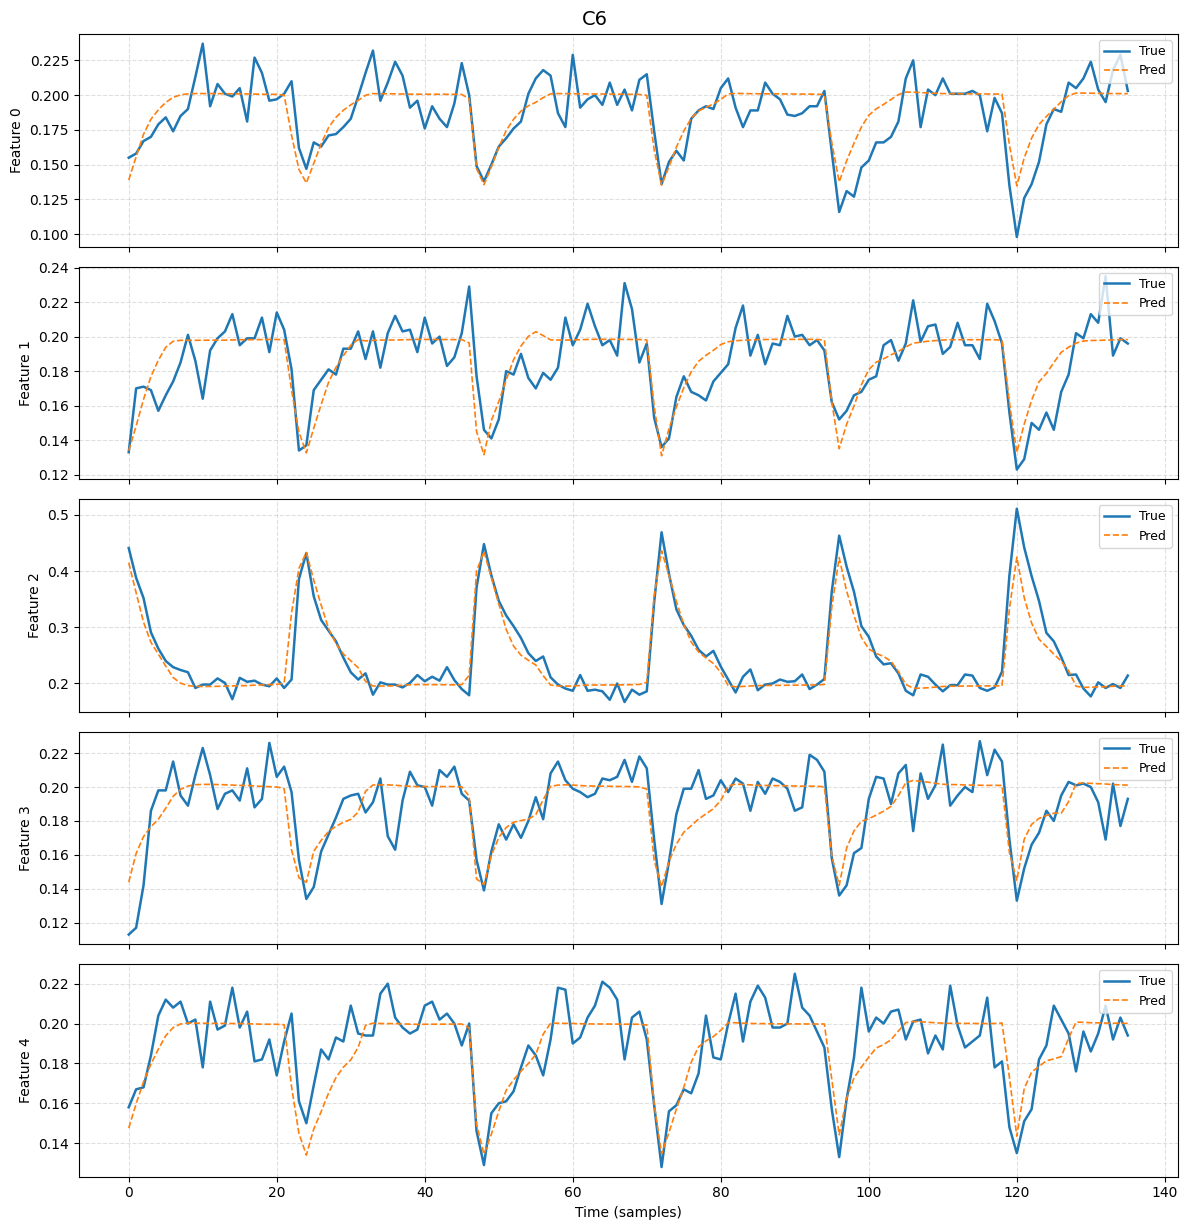

0.098 0.511
0.13096082 0.43604565


In [70]:
# d_model = 64          # embedding dimension
# num_heads = 4         # number of attention heads
# num_layers = 4        # number of transformer encoder layers
# ff_dim = 128          # feed-forward hidden dimension
# dropout = 0.1         # dropout rate
# batch_size = 32
# epochs = 50
# lr = 1e-3

# --- parameters ---
n_agents = 1000
n_locations = 5
center = 2
steps_per_day = 24
n_days = 30
T = steps_per_day * n_days

def create_window_dataset(window_szie):
    X, y = [], []
    for i in range(T - window_szie):
        X.append(df.iloc[i:i+window_szie].values)
        y.append(df.iloc[i+window_szie].values)
    return np.array(X), np.array(y)

config_ts =[
    {"name": "C1", "window": 24, "d_model": 32, "heads": 2, "layers": 2, "ff": 64},
    {"name": "C2", "window": 50, "d_model": 64, "heads": 4, "layers": 4, "ff": 128},
    {"name": "C3", "window": 12, "d_model": 128, "heads": 8, "layers": 4, "ff": 256},
    {"name": "C4", "window": 4, "d_model": 64, "heads": 8, "layers": 6, "ff": 256},
    {"name": "C5", "window": 32, "d_model": 128, "heads": 4, "layers": 2, "ff": 256},
    {"name": "C6", "window": 40, "d_model": 128, "heads": 8, "layers": 6, "ff": 64},
]

results = []

for cfg in config_ts:
    print(f"\n--- Running config: {cfg} ---")

    X, y = create_window_dataset(cfg["window"])

    X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, shuffle=False
    )

    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    X_train_2d = X_train.reshape(-1, X_train.shape[-1])
    scaler_X.fit(X_train_2d)
    scaler_y.fit(y_train)

    X_train_scaled = scaler_X.transform(X_train_2d).reshape(X_train.shape)
    X_test_scaled  = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

    y_train_scaled = scaler_y.transform(y_train)
    y_test_scaled  = scaler_y.transform(y_test)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train = torch.tensor(y_train_scaled, dtype=torch.float32)
    X_val = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_val = torch.tensor(y_test_scaled, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)


    model = TimeSeriesTransformer(
        input_dim=X_train.shape[2],
        d_model=cfg["d_model"],
        n_heads=cfg["heads"],
        n_layers=cfg["layers"],
        ff_dim=cfg["ff"],
        dropout=0.1
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(20):
        model.train()
        train_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(Xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)

        model.eval()
        val_loss, val_r2 = 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                preds = model(Xb).squeeze()
                val_loss += criterion(preds, yb).item() * Xb.size(0)
                val_r2 += r2_score(yb.cpu().numpy(), preds.cpu().numpy()) * Xb.size(0)

        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        val_r2 /= len(val_loader.dataset)

        print(f"Epoch {epoch+1:02d} | Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | Val R2: {val_r2:.4f}")

    model.eval()

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb = Xb.to(device)
            preds = model(Xb)
            y_true_list.append(yb.cpu().numpy())
            y_pred_list.append(preds.cpu().numpy())

    y_true_scaled = np.vstack(y_true_list)
    y_pred_scaled = np.vstack(y_pred_list)

    y_true = scaler_y.inverse_transform(y_true_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    plot_results(y_true, y_pred, cfg["name"])
    print(y_true.min(), y_true.max())
    print(y_pred.min(), y_pred.max())

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    results.append({
        "window": cfg["window"],
        "d_model": cfg["d_model"],
        "heads": cfg["heads"],
        "layers": cfg["layers"],
        "ff_dim": cfg["ff"],
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })



In [71]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("R2", ascending=False).reset_index(drop=True)

df_results

,window,d_model,heads,layers,ff_dim,MSE,RMSE,MAE,R2
0,24,32,2,2,64,0.000223,0.014950,0.011550,0.702064
1,32,128,4,2,256,0.000231,0.015200,0.011659,0.690606
2,50,64,4,4,128,0.000218,0.014761,0.011308,0.686638
3,40,128,8,6,64,0.000284,0.016854,0.012287,0.668021
4,4,64,8,6,256,0.000449,0.021183,0.012367,0.601260
5,12,128,8,4,256,0.000516,0.022705,0.013885,0.567139


In [72]:
best_idx = df_results["R2"].idxmax()
worst_idx = df_results["R2"].idxmin()

print("Best config:\n", df_results.loc[best_idx])
print("\nWorst config:\n", df_results.loc[worst_idx])

Best config:
 window     24.000000
d_model    32.000000
heads       2.000000
layers      2.000000
ff_dim     64.000000
MSE         0.000223
RMSE        0.014950
MAE         0.011550
R2          0.702064
Name: 0, dtype: float64

Worst config:
 window      12.000000
d_model    128.000000
heads        8.000000
layers       4.000000
ff_dim     256.000000
MSE          0.000516
RMSE         0.022705
MAE          0.013885
R2           0.567139
Name: 5, dtype: float64


# Tasks

Write a short report containg the following items. Use plots and tables. Make comments. Deliver as a PDF file.


* Section 3.1.3 Perform sentiment classification using IMDB dataset (35%)
  * Prepare 8 configurations (including various preprocessing parameters).
  * Report results in the table summarizing parameter values and classification results (report accuracy, precision, recall, F1).
  * Display a few reviews from the dataset and print classification result
  * Use Tensorflow or Pytorch library

* Section 3.2.4 Follow the specification (35%)

* Section 3.3.3 Follow the specification (20%)

* Answer the questions (10%)
  1. What is the complexity of attention mechanism with respect to $n$ - the sequence lengths

  2. Is the attention map global or local (pertaining to the sequence).

  3. Which parameters are learned during training the Transformers models for NLP?

  4. What is the role of positional encoding?

  5. Which output data resulting from Transformer Block can be used for classification or regression